<a href="https://colab.research.google.com/github/Sshahsavar/credit-risk-modeling/blob/main/Part_5_Securitization_Forward_Flow_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Part 5: Forward Flow and Securitization
*Credit risk project on Lending Club loans: Part 5 of 5*

## Project map

| Part | Topic | Main question | Main output |
|---|---|---|---|
| 0 | Data Foundation | What data do we need, and how do we prepare it? | Clean loan table and macro data |
| 1 | Loss Given Default (LGD) | How much do we lose when a borrower defaults? | LGD by grade and downturn LGD |
| 2 | PD Algorithm Benchmark | Which model predicts default best? | Choice of PD model |
| 3 | PD Scorecard and Credit Decisions | How do we build, check and use a PD model? | Calibrated PD, score, cut-off, stability check |
| 4 | Macroeconomic Stress Testing | How much would the portfolio lose in a recession? | 9-quarter loss by scenario |
| **5** | **Forward Flow and Securitization (this part)** | **Did the purchased loans perform as expected, and who carries the loss?** | **Monitoring, waterfall, tranche break-even** |

The whole project is built around the expected loss formula, $EL = PD \times LGD \times EAD$. Part 1 measures LGD, Parts 2 and 3 measure PD, and Parts 4 and 5 add EAD, the economy and the investor view.

## What this part does

Parts 1–4 look at the loans from the lender's side. Part 5 looks at them from the side of an **investor** who buys Lending Club loans every month (a **forward flow** agreement) and finances them with a **securitization**. We ask two questions:
1. **Did the loans perform as expected when they were bought?**
2. **Which part of the financing would lose money in a recession?**

## How it connects to the other parts

* **Uses:**
  * the loan table from Part 0;
  * the LGD by grade and the downturn LGD from Part 1;
  * the scenario results from Part 4.
* **Builds on Parts 2 and 3:** Lending Club's sub-grade was the best PD ranking in Part 2, so we use it for the expected loss at purchase. Part 3 found that 2015 loans defaulted more than the model expected, and the monitoring here checks the same loans from the investor's side.
* **Brings everything together:** expected loss is computed as PD × EAD × LGD, the EAD comes from each loan's payment schedule, and stress tests are run on the result. This part shows how the risk parameters from the earlier parts are used to make investment and financing decisions.

## Why it matters for credit risk

Banks, pension funds and asset managers buy large pools of consumer loans and finance them with asset-backed securities (ABS). Their credit risk work is:
* setting the expected loss before buying;
* checking each month's purchases against that expectation;
* sizing the financing so that the senior investors are safe even in a bad recession.

Rating agencies judge each part of the financing (each **tranche**) by how many times the expected loss the pool can suffer before that tranche loses money.

## Methodology

| Step | What we do |
|---|---|
| 2 | Build the forward flow: buy 10% of eligible 36-month loans each month in 2014–2015, with eligibility rules and concentration limits |
| 3 | Set the expected loss at purchase from the loss curves of older loans, by sub-grade: $CNL = PD \times EAD \times LGD$ |
| 4 | Rebuild monthly cash flows for every loan, and compare actual and expected losses for each monthly batch |
| 5 | Finance the pool with Class A (senior), Class B (mezzanine) and equity, and run the monthly payment waterfall |
| 6 | Model the warehouse loan used during the buying period, and test the deal's performance triggers |
| 7 | Stress the tranches and find each tranche's break-even loss |
| 8 | Automate the monthly investor report |

## Main results

* **The pool:** 30,920 loans (\$414.4M) bought in 24 monthly batches. Average interest rate 10.6%, average FICO 704.
* **Expected lifetime loss** (cumulative net loss, CNL) at purchase: **5.34%** of the original balance. **Actual: 5.51%** (1.03× expected).
* **Monitoring:** 18 batches performed as expected, 5 were on *watch* (10–25% above expected) and 1 was in *breach* (May 2015, 26% above). 5 of the 6 flagged batches are from 2015, the same 2015 weakness found in Part 3.
* **The financing held up:** Class A and Class B lost nothing, and no trigger was breached. Equity earned a 1.06× cash multiple (5.1% a year), below the 1.14× (11.4%) expected. The main reasons are lower interest income and faster prepayment, not higher losses.
* **The warehouse needed cash from the investor:** \$7.0M of cure payments (1.7% of purchases) during the buying period, because late and defaulted loans leave the borrowing base.
* **Break-even loss:**

| Tranche | Loses money when the pool CNL reaches | Multiple of expected loss |
|---|---|---|
| Equity | 9.6% | 1.8× |
| Class B | 26.7% | 5.0× |
| Class A | 39.9% | 7.5× |

  A crisis-like loss (1.55× expected, taken from Lending Club's 2007–08 loans) does not hurt the notes. It does cut equity's return to about 3% a year.

Tech stack: Python, pandas, NumPy, SciPy, Matplotlib, Google Colab.

# Step 1: Setup and Assumptions

**Why this step?** We need the loan table (Part 0) and the LGD model (Part 1). We also set every assumption of the deal in one place, so it is easy to test other values.

**How we do it.** We mount Google Drive, read the folder path from the Colab secret `credit_ris_DIR`, and load the files. The main assumptions are:

| Group | Setting | Value | Meaning |
|---|---|---|---|
| Forward flow | `FF_START`, `FF_END` | 2014-01 to 2015-12 | buying period (24 monthly batches) |
| | `PURCHASE_SHARE` | 10% | share of eligible new loans bought each month |
| Expected loss | `DEV_YEARS` | 2010–2013 | older, finished loans used to build the loss curves |
| | `REC_LAG` | 12 months | time from default to recovery (as in Part 1) |
| Deal | `CLASS_A_PCT`, `CLASS_B_PCT` | 60%, 15% | size of the notes as a share of the pool; equity = 25% |
| | `COUPON_A`, `COUPON_B` | 4.0%, 7.0% | yearly interest paid on the notes |
| | `SERVICING_FEE` | 1.0% a year | paid first in the waterfall |
| | `RESERVE_PCT` | 1.0% | cash reserve funded at the start |
| | `OC_TARGET_PCT`, `OC_FLOOR_PCT` | 25%, 1% | target overcollateralization (share of the current and of the original pool) |
| Triggers | `CNL_TRIGGER_MULT` | 1.25 | breach if loss > 125% of the expected curve (tested from month 6) |
| | `OC_TRIGGER` | 1.20 | breach if pool balance ÷ notes < 1.20 |
| Warehouse | `ADVANCE_RATE` | 80% | share of eligible loans the warehouse lender finances |

The Part 4 results are entered as fixed numbers: the 9-quarter loss of each scenario compared with the baseline (1.00, 1.01, 1.02 and 1.06).

### Results

* The LGD by grade from Part 1 is 90.7% (A) to 91.6% (G) in normal times, and 92.2% to 93.0% at 10% unemployment.

In [ ]:
import os
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import expit
from IPython.display import display
warnings.filterwarnings('ignore')

# 1.1. Mount Google Drive and define the project folder
from google.colab import drive
drive.mount('/content/drive')

import google.colab.userdata
PROJECT_DIR = google.colab.userdata.get('credit_ris_DIR')

# 1.2. Load Part 0 and Part 1 outputs
lc = pd.read_pickle(os.path.join(PROJECT_DIR, 'lc_clean.pkl'))
with open(os.path.join(PROJECT_DIR, 'lgd_satellite.json')) as f:
    lgd_sat = json.load(f)
with open(os.path.join(PROJECT_DIR, 'as_of.txt')) as f:
    AS_OF = pd.Period(f.read().strip(), 'M')

# 1.3. Part 4 scenario results (9-quarter loss relative to baseline, from the Part 4 Executive Summary)
PART4_MULTIPLIERS = {'Part 4: Baseline': 1.00, 'Part 4: Adverse': 1.01,
                     'Part 4: Severely Adverse': 1.02, 'Part 4: Realized Path (2019-21)': 1.06}
DOWNTURN_UR = 10.0                     # unemployment rate (%) for the downturn LGD (Part 1 satellite model)

# 1.4. Forward flow, underwriting and deal assumptions
FF_START, FF_END = '2014-01', '2015-12'
PURCHASE_SHARE = 0.10
MIN_FICO, MAX_DTI, ELIGIBLE_GRADES = 670, 30.0, ['A', 'B', 'C', 'D']
GRADE_LIMITS = {'D': 0.20}             # max share of a monthly batch (by balance)
STATE_LIMIT = 0.15                     # max share of any single state
DEV_YEARS = (2010, 2013)
REC_LAG = int(lgd_sat.get('workout_months', 12))
TERM = 36
T = TERM + 4 + REC_LAG                 # months tracked: 36 payments + 4 months to default + recovery lag

CLASS_A_PCT, CLASS_B_PCT = 0.60, 0.15
COUPON_A, COUPON_B = 0.040, 0.070
SERVICING_FEE = 0.010
RESERVE_PCT = 0.010
OC_TARGET_PCT, OC_FLOOR_PCT = 0.25, 0.01
CNL_TRIGGER_MULT, OC_TRIGGER = 1.25, 1.20
TRIGGER_START_MONTH = 6               # triggers are tested from deal month 6 (expected CNL is ~0 before)
ADVANCE_RATE = 0.80

# 1.5. LGD by grade from Part 1: long-run average and downturn (satellite model at DOWNTURN_UR)
LGD_LRA = pd.Series(lgd_sat['lra_by_grade'])
LGD_DOWNTURN = pd.Series({g: max(expit(a + lgd_sat['gamma_ur'] * DOWNTURN_UR), LGD_LRA.get(g, 0))
                          for g, a in lgd_sat['alpha_by_grade'].items()})

print(f"Loans loaded: {len(lc):,} | Snapshot: {AS_OF}")
print(f"LGD (long-run average) by grade: {LGD_LRA.round(3).to_dict()}")
print(f"LGD (downturn, UR = {DOWNTURN_UR:.0f}%) by grade: {LGD_DOWNTURN.round(3).to_dict()}")

Mounted at /content/drive
Loans loaded: 2,260,668 | Snapshot: 2019-03
LGD (long-run average) by grade: {'A': 0.907, 'B': 0.91, 'C': 0.911, 'D': 0.913, 'E': 0.914, 'F': 0.914, 'G': 0.916}
LGD (downturn, UR = 10%) by grade: {'A': 0.922, 'B': 0.925, 'C': 0.927, 'D': 0.928, 'E': 0.929, 'F': 0.929, 'G': 0.93}


# Step 2: Building the Forward Flow

**Why this step?** In a **forward flow agreement**, an investor commits to buy a share of a lender's new loans every month. The investor protects itself with two kinds of rules, and these rules shape the risk of everything that follows.

**How we do it.**

**Eligibility rules** decide which loans may be bought:

| Rule | Limit | Reason |
|---|---|---|
| Term | 36 months | a simple, short pool |
| FICO | ≥ 670 | no weak credit histories |
| DTI | ≤ 30% | limit on borrower debt |
| Grade | A–D | no riskiest price tiers (E–G) |
| Income | > 0 | income must be stated |
| Application | individual | no joint applications |

**Concentration limits** stop one group from taking too much of a batch: grade D at most 20% of each monthly batch, and any one state at most 15%. If a limit is broken, we remove random loans from that group. To bring a group with balance $g$ in a batch of total $B$ down to the limit $\ell$, we remove the balance
$$X = \frac{g - \ell B}{1 - \ell}$$
because removing $X$ from both the group and the total gives $\frac{g - X}{B - X} = \ell$.

The investor then buys a random **10%** of the eligible loans each month. This is how loans are usually shared between several forward-flow buyers.

In [ ]:
print("--- Building the Forward Flow ---")

# 1. Candidate universe: 36-month loans originated during the purchase period
ff_all = lc[(lc['term_m'] == TERM) & (lc['issue_m'] >= pd.Period(FF_START, 'M')) &
            (lc['issue_m'] <= pd.Period(FF_END, 'M'))].copy()

# 2. Eligibility criteria, applied one after the other (eligibility funnel)
app_type = ff_all['application_type'].fillna('Individual').str.lower()
rules = {
    f'FICO >= {MIN_FICO}': ff_all['fico'] >= MIN_FICO,
    f'DTI <= {MAX_DTI:.0f}%': ff_all['dti'] <= MAX_DTI,
    f'Grade {ELIGIBLE_GRADES[0]}-{ELIGIBLE_GRADES[-1]}': ff_all['grade'].isin(ELIGIBLE_GRADES),
    'Stated income > 0': ff_all['annual_inc'] > 0,
    'Individual application': app_type.eq('individual'),
}
mask = pd.Series(True, index=ff_all.index)
funnel = [{'Step': 'All 36-month originations', 'Loans': len(ff_all), 'Balance ($M)': ff_all['funded_amnt'].sum() / 1e6}]
for name, rule in rules.items():
    mask &= rule.fillna(False)
    funnel.append({'Step': f'+ {name}', 'Loans': int(mask.sum()),
                   'Balance ($M)': ff_all.loc[mask, 'funded_amnt'].sum() / 1e6})
eligible = ff_all[mask]

# 3. Forward-flow allocation: buy PURCHASE_SHARE of eligible loans each month
bought = eligible.sample(frac=PURCHASE_SHARE, random_state=42)
funnel.append({'Step': f'x {PURCHASE_SHARE:.0%} forward-flow allocation', 'Loans': len(bought),
               'Balance ($M)': bought['funded_amnt'].sum() / 1e6})

# 4. Concentration limits, enforced batch by batch
def apply_limits(batch, seed=0):
    keep = batch
    for _ in range(5):                                        # iterate: trimming one segment moves the others
        changed = False
        for col in ['grade', 'addr_state']:
            total = keep['funded_amnt'].sum()
            shares = keep.groupby(col)['funded_amnt'].sum() / total
            for key, share in shares.items():
                limit = GRADE_LIMITS.get(key, 1.0) if col == 'grade' else STATE_LIMIT
                if share > limit + 1e-9:
                    excess = (share - limit) * total / (1 - limit)          # X = (g - l*B) / (1 - l)
                    grp = keep[keep[col] == key].sample(frac=1, random_state=seed)
                    n_drop = int(np.searchsorted(grp['funded_amnt'].cumsum().values, excess)) + 1
                    keep = keep.drop(grp.index[:n_drop]); changed = True
        if not changed:
            break
    return keep

pool = pd.concat([apply_limits(b) for _, b in bought.groupby('issue_m')]).copy()
pool['batch'] = pool['issue_m']
funnel.append({'Step': '- concentration limits (grade D <= 20%, state <= 15%)', 'Loans': len(pool),
               'Balance ($M)': pool['funded_amnt'].sum() / 1e6})
print("\n--- Eligibility & Allocation Funnel ---")
display(pd.DataFrame(funnel).round(1))

# 5. Batch summary
batches = pool.groupby('batch').agg(
    Loans=('id', 'size'), Balance_M=('funded_amnt', lambda s: s.sum() / 1e6),
    WAC=('int_rate', lambda s: np.average(s, weights=pool.loc[s.index, 'funded_amnt'])),
    Avg_FICO=('fico', 'mean'), Avg_DTI=('dti', 'mean'))
grade_mix = pool.pivot_table(index='batch', columns='grade', values='funded_amnt', aggfunc='sum').fillna(0)
grade_mix = grade_mix.div(grade_mix.sum(axis=1), axis=0)
max_state = pool.groupby('batch').apply(lambda b: (b.groupby('addr_state')['funded_amnt'].sum() / b['funded_amnt'].sum()).max())
batches['Max State Share'] = max_state
batches['Grade D Share'] = grade_mix.get('D', 0.0)
print(f"\nPurchased: {len(pool):,} loans, ${pool['funded_amnt'].sum() / 1e6:,.1f}M in {pool['batch'].nunique()} monthly batches")
print(f"Pool WAC: {np.average(pool['int_rate'], weights=pool['funded_amnt']):.2f}% | "
      f"Avg FICO: {pool['fico'].mean():.0f} | Avg DTI: {pool['dti'].mean():.1f}%")
display(batches.round(3).head(24))

--- Building the Forward Flow ---

--- Eligibility & Allocation Funnel ---


,Step,Loans,Balance ($M)
0,All 36-month originations,445743,5672.5
1,+ FICO >= 670,355812,4708.8
2,+ DTI <= 30%,321994,4315.9
3,+ Grade A-D,311335,4186.0
4,+ Stated income > 0,311335,4186.0
5,+ Individual application,311218,4184.0
6,x 10% forward-flow allocation,31122,417.3
7,"- concentration limits (grade D <= 20%, state ...",30920,414.4



Purchased: 30,920 loans, $414.4M in 24 monthly batches
Pool WAC: 10.56% | Avg FICO: 704 | Avg DTI: 16.6%


,Loans,Balance_M,WAC,Avg_FICO,Avg_DTI,Max State Share,Grade D Share
batch,,,,,,,
2014-01,820,11.597,11.799,702.268,16.886,0.147,0.074
2014-02,799,10.878,11.575,705.148,16.696,0.139,0.085
2014-03,818,11.385,11.834,701.756,16.451,0.150,0.076
2014-04,953,12.642,11.610,702.698,16.375,0.129,0.074
2014-05,927,12.311,11.277,703.748,16.490,0.150,0.098
2014-06,817,10.362,11.176,704.026,16.173,0.119,0.089
2014-07,1380,18.184,11.328,703.033,16.899,0.144,0.124
2014-08,950,12.606,10.817,707.626,16.495,0.135,0.085
2014-09,552,7.432,10.447,710.361,16.259,0.147,0.078


### Results

| Step | Loans | Balance (\$M) |
|---|---|---|
| All 36-month loans, 2014–2015 | 445,743 | 5,672.5 |
| + FICO ≥ 670 | 355,812 | 4,708.8 |
| + DTI ≤ 30% | 321,994 | 4,315.9 |
| + Grade A–D | 311,335 | 4,186.0 |
| + Income > 0 and individual application | 311,218 | 4,184.0 |
| × 10% forward-flow share | 31,122 | 417.3 |
| − concentration limits | **30,920** | **414.4** |

1. **The FICO rule removes the most loans** (20% of all loans). DTI and grade remove another 10%.
2. **Concentration limits cut only 202 loans.** The state limit is the one that binds: the largest state is close to 15% in almost every batch. Grade D stays at 7–13%, well below its 20% limit.
3. **The pool:** **30,920 loans, \$414.4M**, in 24 monthly batches from \$5.8M (December 2014) to \$32.1M (October 2015). Average interest rate 10.6%, average FICO 704, average DTI 16.6%.
4. **Interest rates fell over time,** from about 11.8% in early 2014 to about 10.1% in late 2015, for loans of similar quality. Lending Club lowered its prices. This matters for the investor's income in Steps 4 and 5.

# Step 3: Expected Loss at Purchase

**Why this step?** Before buying, the investor needs an expectation of how much each batch will lose. Later, actual losses are compared with this expectation. The standard tool is a **static pool analysis**: follow older loans month by month and measure what share of the original balance defaulted, prepaid and was recovered at each **month on book (MOB)**.

**How we do it.**

We build the loss curves by **sub-grade** from the fully finished **2010–2013** loans, because Part 2 showed that Lending Club's sub-grade ranks borrowers best. The expected **cumulative net loss** of a pool with original balance $B_0$ is:
$$CNL = \frac{\sum_i PD_i \times EAD_i \times LGD_i}{\sum_i B_{0,i}}$$
* $PD_i$ is the lifetime default rate of the loan's sub-grade (weighted by balance).
* $EAD_i$ is the balance still owed at default. For a loan that is paid down every month, this is only part of the original amount.
* $LGD_i$ is the grade-level long-run average from Part 1.

**Rebuilding monthly cash flows.** The data has no monthly payment history, so we rebuild it from each loan's terms and final outcome. The scheduled balance of a loan with amount $L$, monthly rate $r$ and instalment $A$ after $m$ payments is
$$B_m = L(1+r)^m - A\,\frac{(1+r)^m - 1}{r}$$
* **Repaid loan:** it pays interest $rB_{m-1}$ and principal $B_{m-1} - B_m$ each month. A prepaid loan pays its whole balance in its payoff month.
* **Defaulted loan:** it pays until its last payment month $\ell$. It is 30, 60 and 90 days late in months $\ell+1$ to $\ell+3$, and defaults in month $\ell+4$ with $EAD = B_\ell$.
* **Recovery:** it arrives 12 months later. For expected loss, it equals $EAD \times (1-LGD)$. For actual loss, it is the loan's real recovery.

--- Building Underwriting Curves (Static-Pool Analysis) ---
Development sample: 167,149 loans issued 2010-2013

--- Underwriting Loss Assumptions by Sub-Grade (eligible grades) ---


,Loans,PD (balance),EAD / Original,LGD,Expected CNL,CNL from curve
A1,5339,0.0297,0.5148,0.9070,0.0139,0.0139
A2,5518,0.0381,0.5121,0.9070,0.0177,0.0177
A3,6336,0.0447,0.5231,0.9070,0.0212,0.0212
A4,9279,0.0581,0.5256,0.9070,0.0277,0.0277
A5,9484,0.0698,0.5040,0.9070,0.0319,0.0319
B1,10971,0.0803,0.5186,0.9099,0.0379,0.0379
B2,13499,0.0880,0.5201,0.9099,0.0416,0.0416
B3,16010,0.1020,0.5350,0.9099,0.0496,0.0496
B4,14155,0.1140,0.5524,0.9099,0.0573,0.0573
B5,10010,0.1309,0.5392,0.9099,0.0642,0.0642



Expected lifetime CNL of the forward-flow pool: 5.34%


batch,2014-01,2014-02,2014-03,2014-04,2014-05,2014-06,2014-07,2014-08,2014-09,2014-10,...,2015-03,2015-04,2015-05,2015-06,2015-07,2015-08,2015-09,2015-10,2015-11,2015-12
Balance ($M),11.5972,10.8785,11.3852,12.6421,12.3112,10.3624,18.1839,12.6056,7.4322,22.7090,...,16.2137,21.7952,19.0249,17.7632,28.1394,22.4795,18.1186,32.0525,24.2240,27.8012
Expected CNL,0.0539,0.0531,0.0557,0.0536,0.0551,0.0562,0.0577,0.0528,0.0502,0.0549,...,0.0541,0.0541,0.0543,0.0519,0.0541,0.0525,0.0535,0.0516,0.0518,0.0526


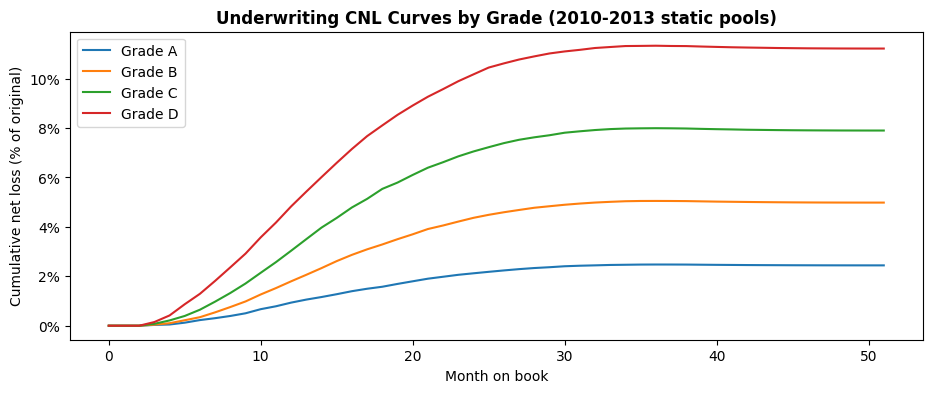

In [ ]:
print("--- Building Underwriting Curves (Static-Pool Analysis) ---")

def scheduled_balance(L, r, A, m):
    """Balance of a level-payment loan after m payments."""
    g = (1 + r) ** m
    return np.clip(L * g - A * (g - 1) / r, 0, None)

KEYS = ['pb_start', 'performing', 'interest', 'sched', 'prepay', 'default', 'recovery', 'dq30', 'dq60', 'dq90']

def reconstruct(frame, group_col, rec_rate):
    """Rebuild monthly loan cash flows and aggregate them by (group, month on book).
    Returns a dict of DataFrames (index = group, columns = MOB 1..T) and the original balance per group."""
    groups = pd.Index(sorted(frame[group_col].unique()))
    agg = {k: np.zeros((len(groups), T + 1)) for k in KEYS}
    orig = np.zeros(len(groups))
    mob = np.arange(T + 1)
    for s in range(0, len(frame), 50_000):                    # chunks keep memory low
        f = frame.iloc[s:s + 50_000]
        gi = groups.get_indexer(f[group_col])
        L, A = f['funded_amnt'].values, f['installment'].values
        r = f['int_rate'].values / 1200
        n = f['term_m'].values
        rr = np.asarray(rec_rate)[s:s + 50_000]
        B = scheduled_balance(L[:, None], r[:, None], A[:, None], np.minimum(mob[None, :], n[:, None]))
        B[mob[None, :] >= n[:, None]] = 0.0
        # Exit logic: last month with a payment, prepayment month, default month
        is_def = f['outcome'].isin(['default', 'delinquent']).values
        is_pre = f['exit_type'].eq('prepaid').values
        months_to_last_pay = (f['last_pymnt_m'].dt.year * 12 + f['last_pymnt_m'].dt.month
                              - f['issue_m'].dt.year * 12 - f['issue_m'].dt.month).fillna(0).values
        lp_def = np.where(f['outcome'].eq('default').values, f['mob_exit'].fillna(4).values - 4, months_to_last_pay)
        last_pay = np.where(is_def, np.clip(lp_def, 0, n - 1),
                            np.where(is_pre, np.clip(np.nan_to_num(f['mob_exit'].values.astype(float), nan=TERM), 1, n), n)).astype(int)
        m = mob[None, :]
        perf = (m >= 1) & (m <= last_pay[:, None])
        B_prev = np.concatenate([B[:, :1], B[:, :-1]], axis=1)          # B_{m-1}
        B_last = B[np.arange(len(f)), last_pay]                         # balance after the last payment
        dq_window = is_def[:, None] & (m > last_pay[:, None]) & (m <= last_pay[:, None] + 4)
        out = {
            'performing': perf * B_prev,
            'pb_start': perf * B_prev + dq_window * B_last[:, None],
            'interest': perf * B_prev * r[:, None],
            'sched': perf * (B_prev - B),
            'prepay': (is_pre[:, None] & (m == last_pay[:, None])) * B,
            'default': (is_def[:, None] & (m == last_pay[:, None] + 4)) * B_last[:, None],
            'recovery': (is_def[:, None] & (m == last_pay[:, None] + 4 + REC_LAG)) * (B_last * rr)[:, None],
            'dq30': (is_def[:, None] & (m == last_pay[:, None] + 1)) * B_last[:, None],
            'dq60': (is_def[:, None] & (m == last_pay[:, None] + 2)) * B_last[:, None],
            'dq90': (is_def[:, None] & (m == last_pay[:, None] + 3)) * B_last[:, None],
        }
        for k in KEYS:
            np.add.at(agg[k], gi, out[k])
        np.add.at(orig, gi, L)
    cols = range(1, T + 1)
    return {k: pd.DataFrame(v[:, 1:], index=groups, columns=cols) for k, v in agg.items()}, pd.Series(orig, index=groups)

# 1. Development sample: matured 36-month vintages 2010-2013
dev = lc[(lc['term_m'] == TERM) & lc['issue_year'].between(*DEV_YEARS)].copy()
dev_rec = 1 - dev['grade'].map(LGD_LRA).fillna(lgd_sat['lra_default_weighted']).values   # underwriting: 1 - LGD
dev_agg, dev_orig = reconstruct(dev, 'sub_grade', dev_rec)

def per_dollar(agg, orig):
    return {k: v.div(orig, axis=0) for k, v in agg.items()}

curves_sg = per_dollar(dev_agg, dev_orig)                          # per $1 of original balance, by sub-grade
dev_agg_g, dev_orig_g = reconstruct(dev, 'grade', dev_rec)         # grade-level fallback
curves_g = per_dollar(dev_agg_g, dev_orig_g)

# 2. PD x EAD x LGD by sub-grade
dev['is_def'] = dev['outcome'].isin(['default', 'delinquent'])
pd_bal = dev[dev['is_def']].groupby('sub_grade')['funded_amnt'].sum() / dev.groupby('sub_grade')['funded_amnt'].sum()
ead_factor = dev_agg['default'].sum(axis=1) / dev[dev['is_def']].groupby('sub_grade')['funded_amnt'].sum()
lgd_sg = pd.Series({sg: LGD_LRA.get(sg[0], lgd_sat['lra_default_weighted']) for sg in dev_orig.index})
uw = pd.DataFrame({'Loans': dev.groupby('sub_grade').size(), 'PD (balance)': pd_bal.fillna(0),
                   'EAD / Original': ead_factor.fillna(0), 'LGD': lgd_sg}).fillna(0)
uw['Expected CNL'] = uw['PD (balance)'] * uw['EAD / Original'] * uw['LGD']
uw['CNL from curve'] = (curves_sg['default'] - curves_sg['recovery']).sum(axis=1)
print(f"Development sample: {len(dev):,} loans issued {DEV_YEARS[0]}-{DEV_YEARS[1]}")
print("\n--- Underwriting Loss Assumptions by Sub-Grade (eligible grades) ---")
display(uw[uw.index.str[0].isin(ELIGIBLE_GRADES)].round(4))

# 3. Expected curves for any set of loans = sub-grade mix x sub-grade curves
def expected_curves(frame, group_col):
    """Expected per-$ curves for each group, as the balance-weighted mix of sub-grade curves."""
    w = frame.pivot_table(index=group_col, columns='sub_grade', values='funded_amnt', aggfunc='sum').fillna(0)
    w = w.div(w.sum(axis=1), axis=0)
    out = {}
    for k in KEYS:
        cur = curves_sg[k].reindex(w.columns)
        missing = cur.isna().all(axis=1)
        if missing.any():                                          # sub-grade never seen in development -> grade curve
            cur.loc[missing] = curves_g[k].reindex([sg[0] for sg in cur.index[missing]]).values
        out[k] = pd.DataFrame(w.values @ cur.fillna(0).values, index=w.index, columns=cur.columns)
    return out

pool_orig_b = pool.groupby('batch')['funded_amnt'].sum()
exp_b = expected_curves(pool, 'batch')                              # per $, by batch
exp_cnl_b = (exp_b['default'] - exp_b['recovery']).cumsum(axis=1)  # expected CNL curve by batch
batch_uw = pd.DataFrame({'Balance ($M)': pool_orig_b / 1e6, 'Expected CNL': exp_cnl_b.iloc[:, -1]})
print(f"\nExpected lifetime CNL of the forward-flow pool: "
      f"{np.average(batch_uw['Expected CNL'], weights=batch_uw['Balance ($M)']):.2%}")
display(batch_uw.round(4).T)

fig, ax = plt.subplots(figsize=(11, 4))
for g in ELIGIBLE_GRADES:
    ax.plot((curves_g['default'] - curves_g['recovery']).loc[g].cumsum().values, label=f'Grade {g}')
ax.set_xlabel('Month on book'); ax.set_ylabel('Cumulative net loss (% of original)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
ax.set_title('Underwriting CNL Curves by Grade (2010-2013 static pools)', fontweight='bold'); ax.legend()
plt.show()

### Results

1. **Development sample:** 167,149 loans issued 2010–2013.
2. **Expected loss rises steadily with sub-grade:**

| Sub-grade | PD (by balance) | EAD / original | LGD | Expected CNL |
|---|---|---|---|---|
| A1 | 3.0% | 0.51 | 90.7% | 1.4% |
| B3 | 10.2% | 0.54 | 91.0% | 5.0% |
| C3 | 16.4% | 0.58 | 91.1% | 8.7% |
| D5 | 21.9% | 0.59 | 91.3% | 11.8% |

3. **EAD is only 50–60% of the original loan.** Loans default after part of the principal is repaid, so expected loss is much smaller than PD × LGD.
4. **The formula matches the curves.** The PD × EAD × LGD result equals the end point of the monthly curve for every sub-grade (column `CNL from curve`). This confirms that the cash-flow rebuild is correct.
5. **Expected loss of the pool: 5.34%** of the original balance, and 5.0–5.8% by batch. Most of the loss arrives between months 6 and 24.

# Step 4: Monitoring Actual vs. Expected Performance

**Why this step?** This is the monthly job of a forward-flow investor: check each batch against the expectation set at purchase. Early warning allows the investor to tighten the eligibility rules, reduce purchases or renegotiate the agreement.

**How we do it.** We follow every batch with its **actual** cash flows and compare it with its **expected** curve. These are the standard measures of every ABS investor report:

| Measure | Formula | What it tells the investor |
|---|---|---|
| Cumulative net loss | $CNL_m = \frac{\sum_{j \le m} (\text{Defaults}_j - \text{Recoveries}_j)}{B_0}$ | total credit loss so far |
| Delinquency (30+ days) | $DQ_m = \frac{\text{balance 30+ days late}_m}{\text{pool balance}_m}$ | early warning: today's late loans are next quarter's defaults |
| Prepayment speed | $SMM_m = \frac{\text{Prepayments}_m}{\text{Balance}_m - \text{Scheduled principal}_m}, \quad CPR = 1-(1-SMM)^{12}$ | how fast the pool shrinks (less interest income) |
| Excess spread | $ES_m = \frac{12 \cdot \text{Interest}_m}{\text{Balance}_m} - \text{servicing fee} - \text{funding cost}$ | interest left each year after costs, the first protection against losses |

**Flags.** A batch is **WATCH** if its actual CNL is more than 10% above expected, and **BREACH** if it is more than 25% above, measured at the latest month observed for all batches. Real recoveries are used only for defaults at least 12 months before the snapshot date; newer defaults get the expected recovery from Part 1.

--- Monitoring Actual Performance vs. Underwriting ---
Comparison point: MOB 39 (latest month observed for every batch)


,Balance ($M),Expected CNL @ MOB 39,Actual CNL @ MOB 39,Actual / Expected,DQ30+ @ MOB 12 (actual),DQ30+ @ MOB 12 (expected),Status
2014-01,11.5972,0.0545,0.0527,0.9670,0.0123,0.0139,OK
2014-02,10.8785,0.0537,0.0395,0.7362,0.0155,0.0138,OK
2014-03,11.3852,0.0563,0.0544,0.9662,0.0130,0.0144,OK
2014-04,12.6421,0.0542,0.0552,1.0174,0.0219,0.0137,OK
2014-05,12.3112,0.0557,0.0622,1.1169,0.0201,0.0142,WATCH
2014-06,10.3624,0.0568,0.0536,0.9439,0.0093,0.0147,OK
2014-07,18.1839,0.0583,0.0610,1.0457,0.0150,0.0150,OK
2014-08,12.6056,0.0534,0.0531,0.9935,0.0195,0.0137,OK
2014-09,7.4322,0.0508,0.0392,0.7711,0.0168,0.0131,OK
2014-10,22.7090,0.0555,0.0581,1.0474,0.0113,0.0143,OK


Status
OK        18
WATCH      5
BREACH     1


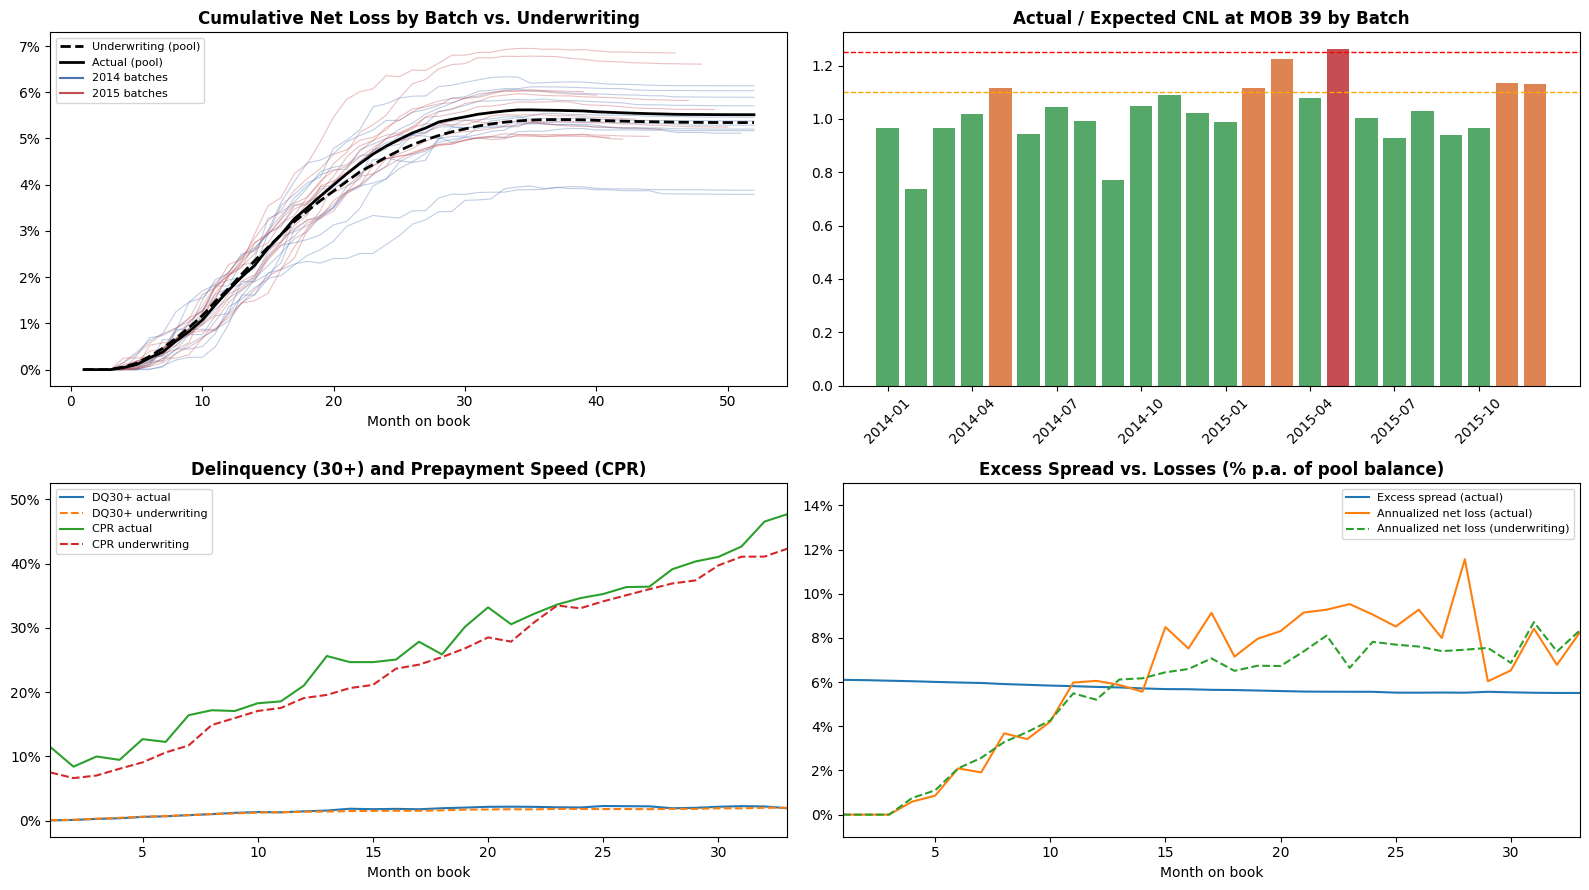


--- Pool Performance at Key Months on Book ---


Actual                                                   Underwriting  \
       CNL   DQ30+     CPR Excess Spread Annualized Net Loss          CNL   
6   0.0025  0.0068  0.1226        0.0598              0.0209       0.0029   
12  0.0172  0.0145  0.2102        0.0578              0.0606       0.0175   
18  0.0350  0.0193  0.2587        0.0564              0.0716       0.0343   
24  0.0483  0.0205  0.3463        0.0556              0.0906       0.0460   
30  0.0547  0.0216  0.4106        0.0554              0.0653       0.0521   
36  0.0561  0.0317     NaN        0.0531             -0.0626       0.0541   

                                                      
     DQ30+     CPR Excess Spread Annualized Net Loss  
6   0.0073  0.1062        0.0714              0.0210  
12  0.0139  0.1908        0.0700              0.0520  
18  0.0160  0.2546        0.0693              0.0651  
24  0.0182  0.3305        0.0684              0.0783  
30  0.0193  0.3973        0.0681              0.0687  
36  0.0282     NaN        0.0658              0.0774

In [ ]:
print("--- Monitoring Actual Performance vs. Underwriting ---")

# 1. Actual recovery rates (realized where the workout is complete, expected otherwise)
lgd_pool = pool['grade'].map(LGD_LRA).fillna(lgd_sat['lra_default_weighted']).values
realized = np.clip(pool['net_recovery'] / pool['ead'].where(pool['ead'] > 0), 0, 1)
default_month = pool['issue_m'] + pool['mob_exit'].fillna(0).astype(int)
months_since_default = (AS_OF.year * 12 + AS_OF.month) - (default_month.dt.year * 12 + default_month.dt.month)
use_realized = pool['outcome'].eq('default') & realized.notna() & (months_since_default >= REC_LAG)
pool_rec = np.where(use_realized, realized, 1 - lgd_pool)

# 2. Reconstruct actual monthly cash flows by batch
act_agg, act_orig = reconstruct(pool, 'batch', pool_rec)
act_b = per_dollar(act_agg, act_orig)
act_cnl_b = (act_b['default'] - act_b['recovery']).cumsum(axis=1)
max_mob = pd.Series({b: (AS_OF.year * 12 + AS_OF.month) - (b.year * 12 + b.month) for b in act_cnl_b.index})
obs = pd.DataFrame(np.arange(1, T + 1)[None, :] <= max_mob.values[:, None], index=act_cnl_b.index, columns=act_cnl_b.columns)
act_cnl_obs = act_cnl_b.where(obs)                                   # hide months after the snapshot

# 3. Batch flags at the latest month observed for all batches
cmp_mob = int(min(max_mob.min(), TERM + 4))
dq_act = (act_agg['dq30'] + act_agg['dq60'] + act_agg['dq90']) / act_agg['pb_start'].replace(0, np.nan)
dq_exp = (exp_b['dq30'] + exp_b['dq60'] + exp_b['dq90']) / exp_b['pb_start'].replace(0, np.nan)
flags = pd.DataFrame({
    'Balance ($M)': act_orig / 1e6,
    f'Expected CNL @ MOB {cmp_mob}': exp_cnl_b[cmp_mob],
    f'Actual CNL @ MOB {cmp_mob}': act_cnl_b[cmp_mob],
    'Actual / Expected': act_cnl_b[cmp_mob] / exp_cnl_b[cmp_mob],
    'DQ30+ @ MOB 12 (actual)': dq_act[12], 'DQ30+ @ MOB 12 (expected)': dq_exp[12]})
flags['Status'] = np.select([flags['Actual / Expected'] > 1.25, flags['Actual / Expected'] > 1.10], ['BREACH', 'WATCH'], 'OK')
print(f"Comparison point: MOB {cmp_mob} (latest month observed for every batch)")
display(flags.round(4))
print(flags['Status'].value_counts().to_string())

# 4. Pool-level performance by month on book (all batches combined, MOB-aligned)
def pool_metrics(agg, orig):
    tot = {k: v.sum(axis=0) for k, v in agg.items()}
    pb = tot['pb_start'].replace(0, np.nan); perf = tot['performing'].replace(0, np.nan)
    smm = (tot['prepay'] / (perf - tot['sched'])).clip(0, 1)
    funding_cost = CLASS_A_PCT * COUPON_A + CLASS_B_PCT * COUPON_B
    return pd.DataFrame({
        'CNL': (tot['default'] - tot['recovery']).cumsum() / orig.sum(),
        'DQ30+': (tot['dq30'] + tot['dq60'] + tot['dq90']) / pb,
        'CPR': 1 - (1 - smm) ** 12,
        'Excess Spread': 12 * tot['interest'] / pb - SERVICING_FEE - funding_cost,
        'Annualized Net Loss': 12 * (tot['default'] - tot['recovery']) / pb})

pm_act = pool_metrics(act_agg, act_orig)
exp_agg_pool = {k: v.mul(pool_orig_b, axis=0) for k, v in exp_b.items()}   # expected $ by batch
pm_exp = pool_metrics(exp_agg_pool, pool_orig_b)

fig, axes = plt.subplots(2, 2, figsize=(16, 9))
years = sorted({b.year for b in act_cnl_obs.index})
colors = dict(zip(years, ['#4C72B0', '#C44E52', '#55A868', '#8172B2']))
for b in act_cnl_obs.index:
    axes[0, 0].plot(act_cnl_obs.columns, act_cnl_obs.loc[b], color=colors[b.year], alpha=0.35, lw=0.8)
axes[0, 0].plot(pm_exp.index, pm_exp['CNL'], 'k--', lw=2, label='Underwriting (pool)')
axes[0, 0].plot(pm_act.index, pm_act['CNL'], color='black', lw=2, label='Actual (pool)')
for y in years:
    axes[0, 0].plot([], [], color=colors[y], label=f'{y} batches')
axes[0, 0].set_title('Cumulative Net Loss by Batch vs. Underwriting', fontweight='bold'); axes[0, 0].legend(fontsize=8)
axes[0, 1].bar(range(len(flags)), flags['Actual / Expected'],
               color=flags['Status'].map({'OK': '#55A868', 'WATCH': '#DD8452', 'BREACH': '#C44E52'}))
axes[0, 1].axhline(1.10, color='orange', ls='--', lw=1); axes[0, 1].axhline(1.25, color='red', ls='--', lw=1)
axes[0, 1].set_xticks(range(0, len(flags), 3)); axes[0, 1].set_xticklabels([str(b) for b in flags.index[::3]], rotation=45)
axes[0, 1].set_title(f'Actual / Expected CNL at MOB {cmp_mob} by Batch', fontweight='bold')
axes[1, 0].plot(pm_act.index, pm_act['DQ30+'], label='DQ30+ actual')
axes[1, 0].plot(pm_exp.index, pm_exp['DQ30+'], '--', label='DQ30+ underwriting')
axes[1, 0].plot(pm_act.index, pm_act['CPR'], label='CPR actual')
axes[1, 0].plot(pm_exp.index, pm_exp['CPR'], '--', label='CPR underwriting')
axes[1, 0].set_xlim(1, TERM - 3); axes[1, 0].set_title('Delinquency (30+) and Prepayment Speed (CPR)', fontweight='bold')
axes[1, 0].legend(fontsize=8)
axes[1, 1].plot(pm_act.index, pm_act['Excess Spread'], label='Excess spread (actual)')
axes[1, 1].plot(pm_act.index, pm_act['Annualized Net Loss'], label='Annualized net loss (actual)')
axes[1, 1].plot(pm_exp.index, pm_exp['Annualized Net Loss'], '--', label='Annualized net loss (underwriting)')
axes[1, 1].set_xlim(1, TERM - 3); axes[1, 1].set_ylim(-0.01, 0.15); axes[1, 1].set_title('Excess Spread vs. Losses (% p.a. of pool balance)', fontweight='bold')
axes[1, 1].legend(fontsize=8)
for ax in axes.flat:
    ax.set_xlabel('Month on book') if ax is not axes[0, 1] else None
for ax in [axes[0, 0], axes[1, 0], axes[1, 1]]:
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
plt.tight_layout(); plt.show()

print("\n--- Pool Performance at Key Months on Book ---")
key_mobs = [6, 12, 18, 24, 30, 36]
display(pd.concat({'Actual': pm_act.loc[key_mobs], 'Underwriting': pm_exp.loc[key_mobs]}, axis=1).round(4))

### Results

1. **The pool performed close to expectations.** At month 39, actual CNL is **5.51%** against **5.34%** expected (1.03×). The actual curve stays very close to the expected curve over the whole life of the pool.
2. **Six batches were flagged:**

| Batch | Actual / expected CNL | Status |
|---|---|---|
| 2015-05 | 1.26 | BREACH |
| 2015-03 | 1.23 | WATCH |
| 2015-11 | 1.14 | WATCH |
| 2015-12 | 1.13 | WATCH |
| 2015-02 | 1.12 | WATCH |
| 2014-05 | 1.12 | WATCH |

   Five of the six are 2015 batches, while 2014 performed at or below expectations. This matches Part 3: 2015 borrowers looked the same as earlier borrowers but defaulted more often. The investor's monitoring finds the same weakness that the PD validation found.
3. **Delinquency gave early warning for the worst batch.** At month 12, the May 2015 batch had 2.4% of its balance 30+ days late, against 1.4% expected. That is a year before its losses became clear. For the whole pool, delinquency at month 12 was 1.45% against 1.39% expected.
4. **Loans prepaid faster than expected.** CPR at month 12 was 21.0% (expected 19.1%) and 34.6% at month 24 (expected 33.1%). Faster prepayment shortens the life of the pool and reduces interest income.
5. **Excess spread is lower than expected**: about 5.8% a year at month 12, against 7.0% expected. The expected curves come from 2010–2013 loans. For the same sub-grade, these older loans most likely had higher interest rates, because Lending Club kept lowering its rates (Step 2 shows rates still falling in 2014–2015). Between months 12 and 24, the yearly net loss rate (6–9%) is higher than the excess spread. Losses in that period are paid from principal collections, and cash to equity falls.

# Step 5: Capital Structure and Cash-Flow Waterfall

**Why this step?** The investor finances the pool by selling notes of different seniority. The **waterfall** decides who is paid first, and therefore who takes the losses. This is the core of a securitization.

**How we do it.** To keep the structure clear, we treat the pool as one **static pool**: all loans are aligned by month on book, as if the deal had started when the first payments began.

**Capital structure** (share of the original pool balance $B_0$):

| Class | Size | Interest | Role |
|---|---|---|---|
| A (senior) | 60% | 4.0% | paid first, safest |
| B (mezzanine) | 15% | 7.0% | paid after A |
| Equity (overcollateralization) | 25% | what is left | takes the first loss, receives the extra cash |
| Reserve account | 1% | – | cash cushion for Class A interest, funded by equity |

**Credit enhancement (CE)** is the loss a tranche can absorb before it loses money. **Overcollateralization (OC)** is the part of the pool not financed by notes:
$$CE_A = \frac{B_0 - A + \text{Reserve}}{B_0} = 41\%, \qquad CE_B = \frac{B_0 - A - B + \text{Reserve}}{B_0} = 26\%, \qquad OC\ \text{ratio} = \frac{\text{Pool balance}}{A + B}$$
**Excess spread** (pool interest minus fees and note interest) is an extra, "soft" protection, because it pays for losses before OC is used.

**Pool cash-flow engine.** We project the pool month by month from four measured inputs:
* the monthly default rate $MDR_m$;
* the share of the pool not paying (delinquent) $NP_m$;
* the scheduled paydown $s_m$ and the prepayment rate $SMM_m$;
* the loss severity (1 − recovery rate), with recoveries 12 months after default.

Stress scenarios multiply the default rate and the non-paying share by a factor $k$, the **loss multiple**. With $k = 1$, the engine gives back exactly the rebuilt cash flows (checked below).

**Waterfall, each month.** Cash collected = interest + principal + prepayments + recoveries. It is paid in this order:
1. **Servicing fee** (1% a year of the pool balance).
2. **Class A interest.** A shortfall is paid from the reserve.
3. **Class B interest.** A shortfall is carried to the next month.
4. **Principal to A, then B**, enough to keep OC at its target, $\max(25\% \times \text{Pool}_{m},\ 1\% \times B_0)$. **If a trigger is breached, all remaining cash goes to principal** until the notes are repaid.
5. **Reserve top-up** back to its target.
6. **What is left goes to equity.**

Any note principal still unpaid after the last recovery is a **loss** for that tranche.

--- Pool Cash-Flow Engine & Waterfall ---
Engine check - actual CNL: reconstructed 5.5144% vs projected 5.5144%

Pool at closing: $414.4M | initial OC ratio = 1.333


,Balance ($M),Share of Pool,Coupon,Credit Enhancement
Class A (Senior),248.6147,0.60,0.04,0.41
Class B (Mezzanine),62.1537,0.15,0.07,0.26
Equity (OC),103.5895,0.25,NaN,0.00
Reserve Account,4.1436,0.01,NaN,NaN



--- Waterfall Result: Actual Performance ---


,Pool CNL,Class A Loss,Class B Loss,Class B Interest Unpaid ($M),Class A WAL (yrs),Equity Multiple,Equity IRR,Trigger Month
Actual,0.0551,0.0,0.0,0.0,1.0216,1.0631,0.0509,NaN



--- Waterfall (first 12 months, $M) ---


,Collections,Servicing,A Interest Paid,B Interest Paid,A Principal,B Principal,Equity Cash,A Balance,B Balance,Pool End,OC Ratio
Month,,,,,,,,,,,
1,17.556,0.345,0.829,0.363,10.434,0.0,5.585,238.181,62.154,400.446,1.333
2,16.180,0.334,0.794,0.363,9.497,0.0,5.192,228.684,62.154,387.784,1.333
3,16.505,0.323,0.762,0.363,9.831,0.0,5.227,218.853,62.154,374.676,1.333
4,16.075,0.312,0.730,0.363,9.737,0.0,4.934,209.116,62.154,361.693,1.333
5,16.865,0.301,0.697,0.363,10.478,0.0,5.026,198.639,62.154,347.723,1.333
6,16.386,0.290,0.662,0.363,10.477,0.0,4.594,188.162,62.154,333.754,1.333
7,17.333,0.278,0.627,0.363,11.227,0.0,4.838,176.935,62.154,318.784,1.333
8,17.089,0.266,0.590,0.363,11.486,0.0,4.385,165.448,62.154,303.469,1.333
9,16.564,0.253,0.551,0.363,11.113,0.0,4.285,154.336,62.154,288.653,1.333


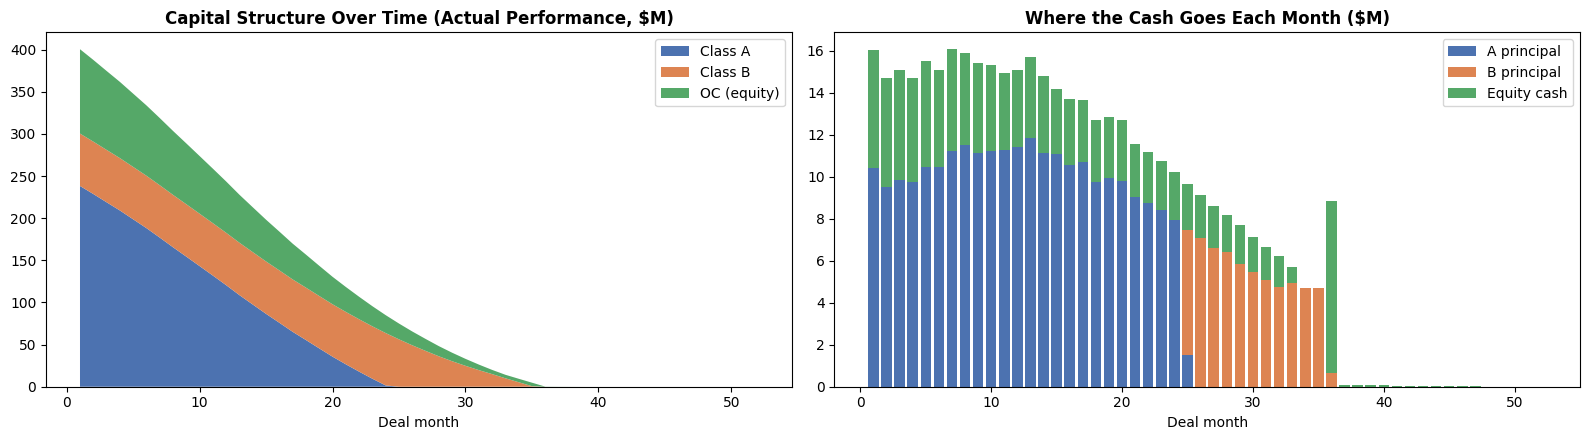

In [ ]:
print("--- Pool Cash-Flow Engine & Waterfall ---")

def pool_vectors(agg, orig):
    """Default, non-payment, amortization, prepayment and severity vectors from aggregated cash flows."""
    tot = {k: np.asarray(v.sum(axis=0), float) for k, v in agg.items()}
    pb, perf = tot['pb_start'], tot['performing']
    with np.errstate(divide='ignore', invalid='ignore'):
        mdr = np.nan_to_num(tot['default'] / pb)
        np_rate = np.nan_to_num(1 - perf / pb)
        coupon = np.nan_to_num(12 * tot['interest'] / perf)
        s = np.nan_to_num(tot['sched'] / perf)
        smm = np.nan_to_num(tot['prepay'] / (perf - tot['sched']))
    sev = 1 - tot['recovery'].sum() / tot['default'].sum()
    return {'mdr': mdr, 'np': np_rate, 'coupon': coupon, 'sched': s, 'smm': np.clip(smm, 0, 1),
            'severity': sev, 'B0': float(np.sum(orig))}

def project_pool(vec, k=1.0, severity=None):
    """Monthly pool cash flows with defaults (and non-payment) scaled by the loss multiple k."""
    sev = vec['severity'] if severity is None else severity
    pb, rows, rec = vec['B0'], [], np.zeros(T + REC_LAG + 2)
    for i in range(T):
        D = min(k * vec['mdr'][i], 1.0) * pb
        NPb = min(max(k * vec['np'][i], 0.0), 1.0) * pb
        perf = max(pb - max(NPb, D), 0.0)
        I, S = perf * vec['coupon'][i] / 12, perf * vec['sched'][i]
        P = vec['smm'][i] * max(perf - S, 0.0)
        rec[i + REC_LAG] += D * (1 - sev)
        pb_end = max(pb - D - S - P, 0.0)
        rows.append({'Month': i + 1, 'Pool Begin': pb, 'Interest': I, 'Scheduled Principal': S, 'Prepayments': P,
                     'Defaults': D, 'Recoveries': rec[i], 'Non-Paying Balance': NPb, 'Pool End': pb_end})
        pb = pb_end
    cf = pd.DataFrame(rows).set_index('Month')
    cf['CNL'] = (cf['Defaults'] - cf['Recoveries']).cumsum() / vec['B0']
    return cf

def irr_monthly(cfs):
    """Annualized IRR by bisection (cfs[0] is the investment, negative)."""
    npv = lambda r: sum(c / (1 + r) ** t for t, c in enumerate(cfs))
    if npv(-0.99) * npv(1.0) > 0:
        return np.nan
    lo, hi = -0.99, 1.0
    for _ in range(200):
        mid = (lo + hi) / 2
        lo, hi = (mid, hi) if npv(mid) > 0 else (lo, mid)
    return (1 + mid) ** 12 - 1

def run_waterfall(cf, exp_cnl_curve, B0):
    A = A0 = CLASS_A_PCT * B0
    Bn = Bn0 = CLASS_B_PCT * B0
    reserve = reserve_target = RESERVE_PCT * B0
    equity_in = B0 - A0 - Bn0 + reserve
    carry_B, triggered, trigger_month, rows = 0.0, False, None, []
    for m, r in cf.iterrows():
        avail = r['Interest'] + r['Scheduled Principal'] + r['Prepayments'] + r['Recoveries']
        serv = min(avail, SERVICING_FEE / 12 * r['Pool Begin']); avail -= serv
        int_A = A * COUPON_A / 12
        pay_iA = min(avail, int_A); avail -= pay_iA
        draw = min(reserve, int_A - pay_iA); reserve -= draw
        short_A = int_A - pay_iA - draw
        int_B = Bn * COUPON_B / 12 + carry_B
        pay_iB = min(avail, int_B); avail -= pay_iB; carry_B = int_B - pay_iB
        pool_end = r['Pool End']
        if triggered:
            principal_due = avail                                   # turbo: all remaining cash to principal
        else:
            oc_target = max(OC_TARGET_PCT * pool_end, OC_FLOOR_PCT * B0)
            principal_due = max(0.0, A + Bn - max(pool_end - oc_target, 0.0))
        prin = min(avail, principal_due)
        pA = min(prin, A); A -= pA
        pB = min(prin - pA, Bn); Bn -= pB
        avail -= pA + pB
        if A + Bn > 1e-6:
            top = min(avail, reserve_target - reserve); reserve += top; avail -= top
        else:                                                        # notes repaid -> release the reserve
            avail += reserve; reserve = 0.0; reserve_target = 0.0
        if m == cf.index[-1] and A + Bn > 1e-6:                      # final month: use the reserve, then write off
            use = min(reserve, A + Bn); uA = min(use, A); uB = min(use - uA, Bn)
            A -= uA; Bn -= uB; pA += uA; pB += uB; reserve -= use
            avail += reserve; reserve = 0.0
        equity_cf = avail
        notes = A + Bn
        oc_ratio = pool_end / notes if notes > 1e-6 else np.inf
        exp_cnl = exp_cnl_curve[m - 1] if m - 1 < len(exp_cnl_curve) else exp_cnl_curve[-1]
        tested = m >= TRIGGER_START_MONTH                              # no trigger tests during the first months
        cnl_breach = tested and exp_cnl > 0 and r['CNL'] > CNL_TRIGGER_MULT * exp_cnl
        oc_breach = tested and notes > 1e-6 and oc_ratio < OC_TRIGGER
        if (cnl_breach or oc_breach) and not triggered:
            triggered, trigger_month = True, m                       # non-curable: stays on
        rows.append({'Month': m, 'Pool End': pool_end, 'CNL': r['CNL'], 'Expected CNL': exp_cnl,
                     'Collections': r['Interest'] + r['Scheduled Principal'] + r['Prepayments'] + r['Recoveries'],
                     'Servicing': serv, 'A Interest Paid': pay_iA + draw, 'A Interest Shortfall': short_A,
                     'B Interest Paid': pay_iB, 'B Interest Deferred': carry_B,
                     'A Principal': pA, 'B Principal': pB, 'A Balance': A, 'B Balance': Bn,
                     'Reserve': reserve, 'Equity Cash': equity_cf, 'OC Ratio': oc_ratio,
                     'Trigger Breached': triggered, 'DQ Balance': r['Non-Paying Balance'] - r['Defaults'],
                     'Pool Begin': r['Pool Begin'], 'Interest': r['Interest'], 'Prepayments': r['Prepayments'],
                     'Scheduled Principal': r['Scheduled Principal'], 'Defaults': r['Defaults'],
                     'Recoveries': r['Recoveries']})
    wf = pd.DataFrame(rows).set_index('Month')
    eq = np.r_[-equity_in, wf['Equity Cash'].values]
    summary = {'Pool CNL': cf['CNL'].iloc[-1],
               'Class A Loss': A / A0, 'Class B Loss': Bn / Bn0, 'Class B Interest Unpaid ($M)': carry_B / 1e6,
               'Class A WAL (yrs)': (wf['A Principal'] * wf.index).sum() / max(wf['A Principal'].sum(), 1e-9) / 12,
               'Equity Multiple': wf['Equity Cash'].sum() / equity_in, 'Equity IRR': irr_monthly(eq),
               'Trigger Month': trigger_month}
    return wf, summary

# 1. Vectors: underwriting (expected) and actual
vec_exp = pool_vectors(exp_agg_pool, pool_orig_b)
vec_act = pool_vectors(act_agg, act_orig)
B0 = vec_exp['B0']
exp_cnl_pool = pm_exp['CNL'].values

# 2. Sanity check: with k = 1 the engine reproduces the reconstructed cash flows
check = project_pool(vec_act)
print(f"Engine check - actual CNL: reconstructed {pm_act['CNL'].iloc[-1]:.4%} vs projected {check['CNL'].iloc[-1]:.4%}")

# 3. Structure at closing
structure = pd.DataFrame({
    'Balance ($M)': [CLASS_A_PCT * B0 / 1e6, CLASS_B_PCT * B0 / 1e6, (1 - CLASS_A_PCT - CLASS_B_PCT) * B0 / 1e6, RESERVE_PCT * B0 / 1e6],
    'Share of Pool': [CLASS_A_PCT, CLASS_B_PCT, 1 - CLASS_A_PCT - CLASS_B_PCT, RESERVE_PCT],
    'Coupon': [COUPON_A, COUPON_B, np.nan, np.nan],
    'Credit Enhancement': [1 - CLASS_A_PCT + RESERVE_PCT, 1 - CLASS_A_PCT - CLASS_B_PCT + RESERVE_PCT, 0.0, np.nan]},
    index=['Class A (Senior)', 'Class B (Mezzanine)', 'Equity (OC)', 'Reserve Account'])
print(f"\nPool at closing: ${B0 / 1e6:,.1f}M | initial OC ratio = {1 / (CLASS_A_PCT + CLASS_B_PCT):.3f}")
display(structure.round(4))

# 4. Waterfall on actual performance
cf_act = project_pool(vec_act)
wf_act, sum_act = run_waterfall(cf_act, exp_cnl_pool, B0)
print("\n--- Waterfall Result: Actual Performance ---")
display(pd.Series(sum_act).to_frame('Actual').T.round(4))
print("\n--- Waterfall (first 12 months, $M) ---")
show = ['Collections', 'Servicing', 'A Interest Paid', 'B Interest Paid', 'A Principal', 'B Principal',
        'Equity Cash', 'A Balance', 'B Balance', 'Pool End', 'OC Ratio']
display((wf_act[show].head(12) / np.r_[[1e6] * (len(show) - 1), [1]]).round(3))

fig, axes = plt.subplots(1, 2, figsize=(16, 4.5))
axes[0].stackplot(wf_act.index, wf_act['A Balance'] / 1e6, wf_act['B Balance'] / 1e6,
                  np.maximum(wf_act['Pool End'] - wf_act['A Balance'] - wf_act['B Balance'], 0) / 1e6,
                  labels=['Class A', 'Class B', 'OC (equity)'], colors=['#4C72B0', '#DD8452', '#55A868'])
axes[0].set_title('Capital Structure Over Time (Actual Performance, $M)', fontweight='bold'); axes[0].legend()
axes[1].bar(wf_act.index, wf_act['A Principal'] / 1e6, label='A principal', color='#4C72B0')
axes[1].bar(wf_act.index, wf_act['B Principal'] / 1e6, bottom=wf_act['A Principal'] / 1e6, label='B principal', color='#DD8452')
axes[1].bar(wf_act.index, wf_act['Equity Cash'] / 1e6, bottom=(wf_act['A Principal'] + wf_act['B Principal']) / 1e6,
            label='Equity cash', color='#55A868')
axes[1].set_title('Where the Cash Goes Each Month ($M)', fontweight='bold'); axes[1].legend()
for ax in axes:
    ax.set_xlabel('Deal month')
plt.tight_layout(); plt.show()

### Results

1. **The engine is correct.** With $k = 1$, the projected CNL (5.5144%) equals the rebuilt CNL (5.5144%).
2. **The deal at the start:** pool \$414.4M; Class A \$248.6M; Class B \$62.2M; equity \$103.6M; reserve \$4.1M. Credit enhancement is 41% for Class A and 26% for Class B, and the OC ratio is 1.333.
3. **With actual performance, both notes are repaid in full.** Class A is repaid first, with an average life of 1.0 year; it is almost fully repaid by month 24. Class B is repaid after that. Neither misses any interest.
4. **Equity earns less than expected.** Equity receives a cash multiple of **1.06×** (5.1% a year), against 1.14× (11.4%) in the expected case. Actual losses were only 3% above expected, so most of the gap comes from lower interest income: lower loan rates than in the older loans behind the expected curves, and faster prepayment. **Equity is the tranche most exposed to both credit losses and prepayment.**
5. **The cash flow charts** show equity receiving about \$5.6M in month 1, falling to \$3.7M by month 12 as the pool shrinks. Class A takes most of the principal in the first two years.

# Step 6: Warehouse Borrowing Base and Triggers

**Why this step?** Two tools protect lenders during the life of the deal.
* **During the buying period,** the loans are financed by a **warehouse** loan from a bank, before the securitization. The bank lends only against good loans.
* **After the securitization,** **triggers** protect the note holders if losses grow too fast.

**How we do it.**

**Warehouse.** The bank lends a fixed share (the **advance rate**, 80%) of the eligible loan balance. The **borrowing base** is what the loans can support:
$$\text{Borrowing base}_t = \text{Advance rate} \times \text{Eligible balance}_t$$
Loans that become 30+ days late are no longer eligible. If the loan outstanding is larger than the borrowing base, the investor must **pay the difference in cash** (a "cure"):
$$\text{Cure}_t = \max(0,\ \text{Advance}_t - \text{Borrowing base}_t)$$
We follow this month by month during 2014–2015, as batches are bought, paid down, become late and default.

**Securitization triggers.** Two tests protect the note holders:
* **Loss trigger:** CNL > 125% of the expected loss curve;
* **OC trigger:** pool balance ÷ (A + B) < 1.20.

Once a trigger is breached, it stays breached. All extra cash then goes from equity to repaying Class A, then Class B (a "cash sweep").


--- Warehouse Borrowing Base ---
Peak advance: $221.2M | Total cures: $7.04M (1.70% of purchases)


,Eligible Balance,Borrowing Base,Advance Outstanding,Ineligible (Delinquent),Cure Payment
Month,,,,,
2014-01,11.60,9.28,9.28,0.00,0.00
2014-04,44.39,35.51,35.51,0.08,0.02
2014-07,79.88,63.90,63.90,0.21,0.10
2014-10,112.64,90.11,90.11,0.52,0.15
2015-01,139.15,111.32,111.32,0.95,0.32
2015-04,171.92,137.54,137.54,1.57,0.44
2015-07,210.09,168.07,168.07,2.03,0.58
2015-10,249.38,199.51,199.51,2.86,0.67



--- Securitization Triggers (Actual Performance) ---
CNL trigger: 125% of underwriting curve | OC trigger: ratio < 1.20
First breach: none


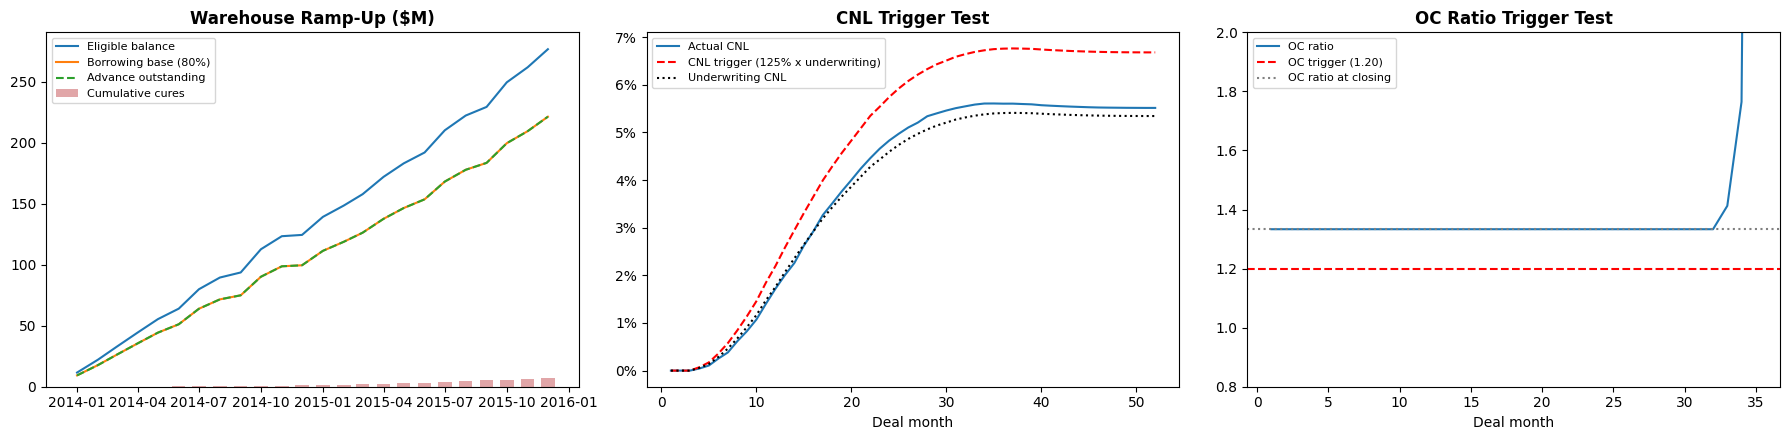

In [ ]:
print("--- Warehouse Borrowing Base ---")

# 1. Calendar-month view of the forward-flow pool (batch + month on book)
start = pd.Period(FF_START, 'M')
offset = pd.Series({b: (b.year * 12 + b.month) - (start.year * 12 + start.month) for b in act_agg['pb_start'].index})
n_cal = int(offset.max()) + T + 2
cal = {k: np.zeros(n_cal) for k in ['purchases', 'eligible', 'delinquent', 'principal', 'defaults']}
for b, o in offset.items():
    cal['purchases'][o] += act_orig[b]
    idx = o + np.arange(1, T + 1)
    cal['eligible'][idx] += act_agg['performing'].loc[b].values                                  # current & paying
    cal['delinquent'][idx] += (act_agg['pb_start'] - act_agg['performing']).loc[b].values
    cal['principal'][idx] += (act_agg['sched'] + act_agg['prepay']).loc[b].values
    cal['defaults'][idx] += act_agg['default'].loc[b].values
months = pd.period_range(start, periods=n_cal, freq='M')
wh = pd.DataFrame(cal, index=months)

# 2. Advance, borrowing base and cures (ramp-up: purchases through FF_END, then take-out by the securitization)
ramp = wh.loc[:pd.Period(FF_END, 'M')].copy()
ramp['eligible_end'] = wh['eligible'].shift(-1).loc[ramp.index]    # current loans at month end (incl. new purchases)
advance, rows = 0.0, []
for t, r in ramp.iterrows():
    advance += ADVANCE_RATE * r['purchases'] - ADVANCE_RATE * r['principal']   # draw on purchases, repay from principal
    bb = ADVANCE_RATE * r['eligible_end']                                          # borrowing base at month end
    cure = max(0.0, advance - bb)                                                  # delinquent loans leave the base
    advance -= cure
    rows.append({'Month': t, 'Eligible Balance': r['eligible_end'], 'Borrowing Base': bb,
                 'Advance Outstanding': advance, 'Ineligible (Delinquent)': r['delinquent'], 'Cure Payment': cure})
bb_df = pd.DataFrame(rows).set_index('Month')
print(f"Peak advance: ${bb_df['Advance Outstanding'].max() / 1e6:,.1f}M | "
      f"Total cures: ${bb_df['Cure Payment'].sum() / 1e6:,.2f}M "
      f"({bb_df['Cure Payment'].sum() / ramp['purchases'].sum():.2%} of purchases)")
display((bb_df.iloc[::3] / 1e6).round(2))

# 3. Securitization trigger tests on actual performance
first_breach = sum_act['Trigger Month']
print(f"\n--- Securitization Triggers (Actual Performance) ---")
print(f"CNL trigger: {CNL_TRIGGER_MULT:.0%} of underwriting curve | OC trigger: ratio < {OC_TRIGGER:.2f}")
print(f"First breach: {'none' if first_breach is None else f'deal month {first_breach}'}")

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
axes[0].plot(bb_df.index.to_timestamp(), bb_df['Eligible Balance'] / 1e6, label='Eligible balance')
axes[0].plot(bb_df.index.to_timestamp(), bb_df['Borrowing Base'] / 1e6, label=f'Borrowing base ({ADVANCE_RATE:.0%})')
axes[0].plot(bb_df.index.to_timestamp(), bb_df['Advance Outstanding'] / 1e6, '--', label='Advance outstanding')
axes[0].bar(bb_df.index.to_timestamp(), bb_df['Cure Payment'].cumsum() / 1e6, width=20, color='#C44E52', alpha=0.5,
            label='Cumulative cures')
axes[0].set_title('Warehouse Ramp-Up ($M)', fontweight='bold'); axes[0].legend(fontsize=8)
axes[1].plot(wf_act.index, wf_act['CNL'], label='Actual CNL')
axes[1].plot(wf_act.index, CNL_TRIGGER_MULT * wf_act['Expected CNL'], 'r--', label=f'CNL trigger ({CNL_TRIGGER_MULT:.0%} x underwriting)')
axes[1].plot(wf_act.index, wf_act['Expected CNL'], 'k:', label='Underwriting CNL')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
axes[1].set_title('CNL Trigger Test', fontweight='bold'); axes[1].legend(fontsize=8)
oc_plot = wf_act['OC Ratio'].replace(np.inf, np.nan)
axes[2].plot(wf_act.index, oc_plot, label='OC ratio')
axes[2].axhline(OC_TRIGGER, color='red', ls='--', label=f'OC trigger ({OC_TRIGGER:.2f})')
axes[2].axhline(1 / (CLASS_A_PCT + CLASS_B_PCT), color='grey', ls=':', label='OC ratio at closing')
axes[2].set_ylim(0.8, max(2.0, np.nanmin([oc_plot.quantile(0.8), 3]))); axes[2].set_title('OC Ratio Trigger Test', fontweight='bold')
axes[2].legend(fontsize=8)
for ax in axes[1:]:
    ax.set_xlabel('Deal month')
plt.tight_layout(); plt.show()

### Results

1. **Warehouse.** The advance grows with the purchases and peaks at **\$221.2M** at the end of the buying period. Each dollar of loans that becomes 30+ days late or defaults leaves the borrowing base, so the investor must repay 80 cents of the advance in cash. Monthly cure payments grow from almost zero in early 2014 to about \$0.6–0.7M in late 2015, as the portfolio ages and delinquent loans reach \$2.9M. In total, the investor paid **\$7.0M of cures (1.7% of purchases)**. This is the main message of this step: rising delinquencies create a **cash need** for the investor before any loss is final, so a forward flow investor must keep a liquidity buffer.
2. **No trigger was breached with actual performance.** Actual CNL stayed below the 125% trigger line in every month. The OC ratio stayed at its 1.333 target until about month 32, and then rose as the notes were repaid.
3. **Triggers matter in stress.** In the stress scenarios of Step 7, the loss trigger breaches in month 6. From that point, equity stops receiving cash and all extra cash repays the notes. This is how triggers move risk from note holders to equity.

# Step 7: Tranche Stress Tests and Break-Even Loss

**Why this step?** The final question of the project: **who loses money in a recession?** Rating agencies judge a tranche by how many times the expected loss the pool can suffer before that tranche loses money. The higher this multiple, the safer the tranche.

**How we do it.** We run three kinds of stress:
1. **The Part 4 scenarios.** Loss multiples 1.00, 1.01, 1.02 and 1.06; the severe and real-path scenarios also use the downturn LGD from Part 1. Part 4 showed that its PD model understates the effect of the economy, so these are a lower bound.
2. **A recession multiple from our own data.** Lending Club's 2007–08 loans went through the financial crisis. Their actual CNL divided by the CNL our expected curves predict for them gives a recession multiple. Lending Club was small then, so this is only a guide.
3. **Standard multiples:** 2× and 3× the expected loss.

**Break-even loss.** For each tranche, we search for the smallest loss multiple $k^*$ at which it loses principal (for equity: at which it does not get its investment back):
$$k^*_{\text{tranche}} = \min\{k : \text{Tranche loss}(k) > 0\}, \qquad \text{Break-even CNL} = CNL(k^*), \qquad \text{Coverage multiple} = \frac{CNL(k^*)}{CNL_{\text{expected}}}$$

--- Tranche Stress Testing ---
2007-08 vintages: 2,996 loans | actual CNL 14.50% vs underwriting 9.37% -> recession multiple 1.55x

Severity: expected 91.06% | downturn 92.58%


,Pool CNL,CNL / Expected,Trigger Month,Class A Loss,Class B Loss,Class B Interest Unpaid ($M),Equity Multiple,Equity IRR,Class A WAL (yrs)
Underwriting (expected),0.0534,1.0000,NaN,0.0,0.0,0.0,1.1422,0.1139,1.0655
Actual performance,0.0551,1.0319,NaN,0.0,0.0,0.0,1.0631,0.0509,1.0216
Part 4: Baseline,0.0534,1.0000,NaN,0.0,0.0,0.0,1.1422,0.1139,1.0655
Part 4: Adverse,0.0540,1.0096,NaN,0.0,0.0,0.0,1.1401,0.1122,1.0652
Part 4: Severely Adverse,0.0554,1.0362,NaN,0.0,0.0,0.0,1.1345,0.1080,1.0650
Part 4: Realized Path (2019-21),0.0574,1.0750,NaN,0.0,0.0,0.0,1.1258,0.1011,1.0639
Recession multiple (2007-08 vintages),0.0822,1.5375,6.0,0.0,0.0,0.0,1.0617,0.0323,0.9012
2x expected,0.1025,1.9185,6.0,0.0,0.0,0.0,0.9727,-0.0146,0.9063
3x expected,0.1476,2.7628,6.0,0.0,0.0,0.0,0.7757,-0.1267,0.9184



--- Break-Even Analysis (how much can the pool lose before each tranche is hit?) ---


,Break-even k,Break-even CNL,Coverage Multiple
Equity,1.867,0.096,1.801
Class B,6.115,0.267,4.988
Class A,10.821,0.399,7.464


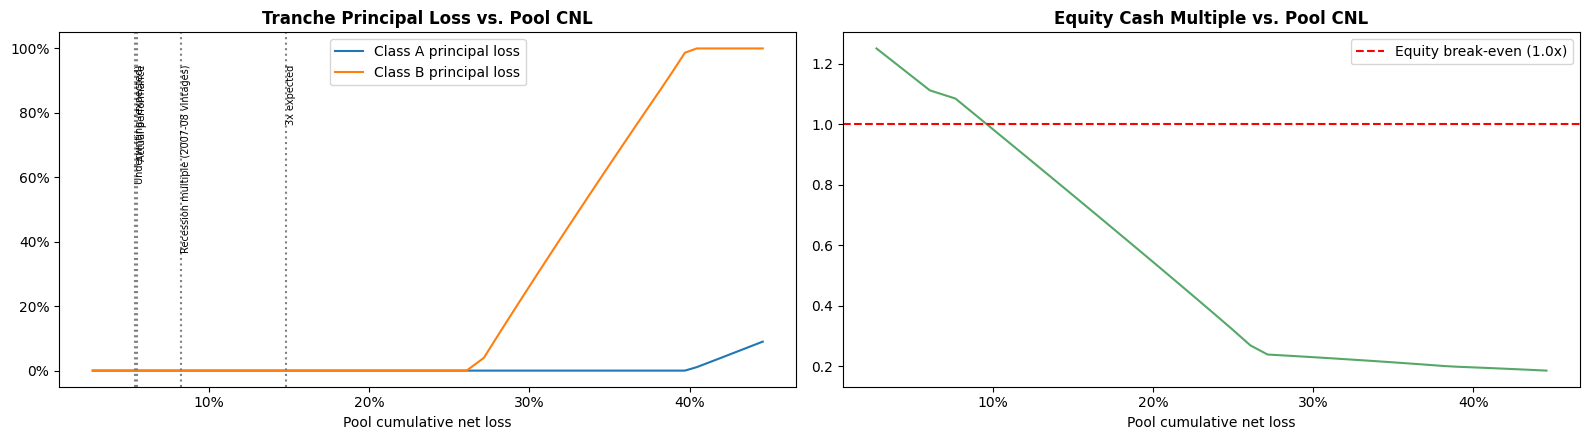

In [ ]:
print("--- Tranche Stress Testing ---")

# 1. In-sample recession multiple from the 2007-08 vintages
hist = lc[(lc['term_m'] == TERM) & lc['issue_year'].between(2007, 2008)].copy()
if len(hist) > 0:
    hist_rec = np.clip(hist['net_recovery'] / hist['ead'].where(hist['ead'] > 0), 0, 1).fillna(
        1 - hist['grade'].map(LGD_LRA).fillna(lgd_sat['lra_default_weighted'])).values
    hist_agg, hist_orig = reconstruct(hist, 'issue_year', hist_rec)
    hist['all'] = 'all'
    hist_exp = expected_curves(hist, 'all')
    hist_expected = float((hist_exp['default'] - hist_exp['recovery']).sum(axis=1).iloc[0])
    HIST_MULT = float((hist_agg['default'] - hist_agg['recovery']).values.sum() / hist_orig.sum() / hist_expected)
    print(f"2007-08 vintages: {len(hist):,} loans | actual CNL "
          f"{(hist_agg['default'] - hist_agg['recovery']).values.sum() / hist_orig.sum():.2%} vs underwriting "
          f"{hist_expected:.2%} -> recession multiple {HIST_MULT:.2f}x")
else:
    HIST_MULT = 2.0
    print("No 2007-08 vintages available; recession multiple set to 2.0x")

# 2. Scenario runs
sev_exp = vec_exp['severity']
lgd_lra_pool = float(np.average(pool['grade'].map(LGD_LRA).fillna(lgd_sat['lra_default_weighted']), weights=pool['funded_amnt']))
lgd_down_pool = float(np.average(pool['grade'].map(LGD_DOWNTURN).fillna(LGD_DOWNTURN.mean()), weights=pool['funded_amnt']))
sev_down = min(sev_exp * lgd_down_pool / lgd_lra_pool, 1.0)       # downturn LGD from Part 1, scaled to the pool
scenarios = {'Underwriting (expected)': (vec_exp, 1.0, sev_exp), 'Actual performance': (vec_act, 1.0, None)}
for name, mult in PART4_MULTIPLIERS.items():
    scenarios[name] = (vec_exp, mult, sev_down if ('Severely' in name or 'Realized' in name) else sev_exp)
scenarios['Recession multiple (2007-08 vintages)'] = (vec_exp, HIST_MULT, sev_down)
scenarios['2x expected'] = (vec_exp, 2.0, sev_exp)
scenarios['3x expected'] = (vec_exp, 3.0, sev_exp)

results, runs = {}, {}
for name, (vec, k, sev) in scenarios.items():
    cf = project_pool(vec, k, sev)
    runs[name], results[name] = run_waterfall(cf, exp_cnl_pool, B0)
stress = pd.DataFrame(results).T
stress['CNL / Expected'] = stress['Pool CNL'] / stress.loc['Underwriting (expected)', 'Pool CNL']
print(f"\nSeverity: expected {sev_exp:.2%} | downturn {sev_down:.2%}")
display(stress[['Pool CNL', 'CNL / Expected', 'Trigger Month', 'Class A Loss', 'Class B Loss',
                'Class B Interest Unpaid ($M)', 'Equity Multiple', 'Equity IRR', 'Class A WAL (yrs)']].round(4))

# 3. Break-even loss multiple for each tranche (bisection on k)
def tranche_hit(k, tranche):
    s = run_waterfall(project_pool(vec_exp, k, sev_exp), exp_cnl_pool, B0)[1]
    return {'Class A': s['Class A Loss'] > 1e-4, 'Class B': s['Class B Loss'] > 1e-4,
            'Equity': s['Equity Multiple'] < 1.0}[tranche], s['Pool CNL']

exp_cnl_final = stress.loc['Underwriting (expected)', 'Pool CNL']
breakeven = {}
for tranche in ['Equity', 'Class B', 'Class A']:
    lo, hi = 0.0, 30.0
    if tranche_hit(lo, tranche)[0]:
        breakeven[tranche] = {'Break-even k': 0.0, 'Break-even CNL': 0.0, 'Coverage Multiple': 0.0}
        continue
    if not tranche_hit(hi, tranche)[0]:
        breakeven[tranche] = {'Break-even k': np.inf, 'Break-even CNL': np.nan, 'Coverage Multiple': np.inf}
        continue
    for _ in range(30):
        mid = (lo + hi) / 2
        lo, hi = (lo, mid) if tranche_hit(mid, tranche)[0] else (mid, hi)
    cnl_at = tranche_hit(hi, tranche)[1]
    breakeven[tranche] = {'Break-even k': hi, 'Break-even CNL': cnl_at, 'Coverage Multiple': cnl_at / exp_cnl_final}
be = pd.DataFrame(breakeven).T
print("\n--- Break-Even Analysis (how much can the pool lose before each tranche is hit?) ---")
display(be.round(3))

# 4. Tranche loss curves
grid = np.linspace(0.5, max(6.0, float(np.nanmax(be['Break-even k'].replace(np.inf, np.nan))) * 1.2), 40)
curve = []
for k in grid:
    s = run_waterfall(project_pool(vec_exp, k, sev_exp), exp_cnl_pool, B0)[1]
    curve.append({'k': k, 'Pool CNL': s['Pool CNL'], 'Class A Loss': s['Class A Loss'],
                  'Class B Loss': s['Class B Loss'], 'Equity Multiple': s['Equity Multiple']})
curve = pd.DataFrame(curve)
fig, axes = plt.subplots(1, 2, figsize=(16, 4.5))
axes[0].plot(curve['Pool CNL'], curve['Class A Loss'], label='Class A principal loss')
axes[0].plot(curve['Pool CNL'], curve['Class B Loss'], label='Class B principal loss')
for name in ['Underwriting (expected)', 'Actual performance', 'Recession multiple (2007-08 vintages)', '3x expected']:
    axes[0].axvline(stress.loc[name, 'Pool CNL'], ls=':', color='grey')
    axes[0].text(stress.loc[name, 'Pool CNL'], 0.95, name, rotation=90, fontsize=7, va='top')
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
axes[0].set_xlabel('Pool cumulative net loss'); axes[0].set_title('Tranche Principal Loss vs. Pool CNL', fontweight='bold')
axes[0].legend()
axes[1].plot(curve['Pool CNL'], curve['Equity Multiple'], color='#55A868')
axes[1].axhline(1.0, color='red', ls='--', label='Equity break-even (1.0x)')
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
axes[1].set_xlabel('Pool cumulative net loss'); axes[1].set_title('Equity Cash Multiple vs. Pool CNL', fontweight='bold')
axes[1].legend()
plt.tight_layout(); plt.show()

### Results

1. **Recession multiple from our data: 1.55×.** The 2,996 loans from 2007–08 lost 14.5%, against 9.4% predicted by our expected curves. The severity (loss per default) rises from 91.1% to 92.6% in the downturn cases.
2. **Stress results:**

| Scenario | Pool CNL | × expected | Trigger month | Class A loss | Class B loss | Equity multiple | Equity return (per year) |
|---|---|---|---|---|---|---|---|
| Expected | 5.34% | 1.00 | – | 0% | 0% | 1.14× | 11.4% |
| Actual | 5.51% | 1.03 | – | 0% | 0% | 1.06× | 5.1% |
| Part 4 severely adverse | 5.54% | 1.04 | – | 0% | 0% | 1.13× | 10.8% |
| Part 4 real path | 5.74% | 1.08 | – | 0% | 0% | 1.13× | 10.1% |
| Recession multiple (2007–08) | 8.22% | 1.54 | 6 | 0% | 0% | 1.06× | 3.2% |
| 2× expected | 10.25% | 1.92 | 6 | 0% | 0% | 0.97× | −1.5% |
| 3× expected | 14.76% | 2.76 | 6 | 0% | 0% | 0.78× | −12.7% |

3. **Break-even loss for each tranche:**

| Tranche | Break-even CNL | Multiple of expected loss |
|---|---|---|
| Equity | 9.6% | 1.8× |
| Class B | 26.7% | 5.0× |
| Class A | 39.9% | 7.5× |

4. **What this means.**
   * **Class A** can take a pool loss of about 40%, 7.5 times the expected loss. It is very safe.
   * **Class B** is safe up to about 27% (5.0×). It takes no loss even in the 3× case.
   * **Equity** loses money when the pool loss passes about 9.6% (1.8×). A crisis-like loss (1.55×) keeps equity just above water (1.06×, 3.2% a year), and 2× expected wipes out its return.
   * **The Part 4 scenarios barely move the tranches** (within 8% of expected loss). As Part 4 showed, this is a weakness of that model, not proof that the structure is safe. The recession multiple from our own data is a better guide.

# Step 8: Automated Monthly Investor Report

**Why this step?** An investor follows many deals every month. A report that is built by hand is slow and can have errors. One function, `investor_report`, turns the waterfall results into a standard report for any month:
* **pool performance:** balance, CNL vs. expected, delinquency, CPR, excess spread;
* **trigger status:** the loss and OC tests against their limits;
* **tranche coverage:** each tranche's balance, current credit enhancement, and coverage = CE ÷ remaining expected loss;
* **alerts:** rule-based messages in plain English, so the report can be read without the notebook.

`report_history` runs the report for every quarter and saves the table to Google Drive. The same code can run each month when new loan data arrives, and the alert messages could be passed to an AI language model to write the investor commentary.

In [ ]:
def investor_report(wf, month, deal_name='LC Forward Flow 2014-2015 (static pool)', verbose=True):
    r = wf.loc[month]
    remaining_exp_loss = max(exp_cnl_pool[-1] - r['Expected CNL'], 0) * B0
    pool_end, A, Bn, res = r['Pool End'], r['A Balance'], r['B Balance'], r['Reserve']
    ce_A = (pool_end + res - A) / pool_end if pool_end > 0 else np.nan
    ce_B = (pool_end + res - A - Bn) / pool_end if pool_end > 0 else np.nan
    cov = lambda ce_dollars: ce_dollars / remaining_exp_loss if remaining_exp_loss > 0 else np.inf
    smm = r['Prepayments'] / max(r['Pool Begin'] - r['Defaults'] - r['DQ Balance'] - r['Scheduled Principal'], 1e-9)
    kpi = {
        'Deal Month': month, 'Pool Balance ($M)': pool_end / 1e6, 'Pool Factor': pool_end / B0,
        'CNL': r['CNL'], 'Underwriting CNL': r['Expected CNL'],
        'CNL / Underwriting': r['CNL'] / r['Expected CNL'] if r['Expected CNL'] > 0 else np.nan,
        'DQ30+ (% pool)': r['DQ Balance'] / r['Pool Begin'] if r['Pool Begin'] > 0 else 0.0,
        'CPR': 1 - (1 - min(max(smm, 0), 1)) ** 12,
        'Excess Spread (p.a.)': 12 * (r['Interest'] - r['Servicing'] - r['A Interest Paid'] - r['B Interest Paid']) / r['Pool Begin']
                                if r['Pool Begin'] > 0 else 0.0,
        'OC Ratio': r['OC Ratio'], 'Trigger Status': 'BREACHED - cash sweep' if r['Trigger Breached'] else 'Pass',
        'Class A Balance ($M)': A / 1e6, 'Class A CE': ce_A, 'Class A Coverage (x)': cov(pool_end + res - A),
        'Class B Balance ($M)': Bn / 1e6, 'Class B CE': ce_B, 'Class B Coverage (x)': cov(pool_end + res - A - Bn),
        'Equity Cash This Month ($M)': r['Equity Cash'] / 1e6}
    alerts = []
    if kpi['CNL / Underwriting'] > 1.25:
        alerts.append(f"ALERT: CNL is {kpi['CNL / Underwriting'] - 1:.0%} above underwriting.")
    elif kpi['CNL / Underwriting'] > 1.10:
        alerts.append(f"WATCH: CNL is {kpi['CNL / Underwriting'] - 1:.0%} above underwriting.")
    if r['Trigger Breached']:
        alerts.append("ALERT: performance trigger breached - excess cash is swept to the notes, equity receives nothing.")
    if kpi['Pool Factor'] > 0.05 and kpi['Excess Spread (p.a.)'] < 12 * (r['Defaults'] - r['Recoveries']) / max(r['Pool Begin'], 1e-9):
        alerts.append("WATCH: net losses are above excess spread - principal is used to keep OC at target, so equity cash falls.")
    if kpi['Class B Coverage (x)'] < 1.0 and Bn > 0:
        alerts.append("ALERT: Class B credit enhancement no longer covers the remaining expected loss.")
    if r['A Interest Shortfall'] > 0:
        alerts.append("ALERT: Class A interest shortfall (event of default).")
    kpi['Alerts'] = ' | '.join(alerts) if alerts else 'No alerts'
    if verbose:
        print(f"=== Investor Report | {deal_name} | Deal Month {month} ===")
        print(f"Pool: ${kpi['Pool Balance ($M)']:,.1f}M (factor {kpi['Pool Factor']:.1%}) | CNL {kpi['CNL']:.2%} "
              f"vs underwriting {kpi['Underwriting CNL']:.2%} | DQ30+ {kpi['DQ30+ (% pool)']:.2%} | CPR {kpi['CPR']:.1%} "
              f"| Excess spread {kpi['Excess Spread (p.a.)']:.1%} p.a.")
        print(f"Triggers: {kpi['Trigger Status']} | OC ratio {kpi['OC Ratio']:.3f} (trigger {OC_TRIGGER:.2f})")
        print(f"Class A: ${kpi['Class A Balance ($M)']:,.1f}M, CE {kpi['Class A CE']:.1%}, coverage {kpi['Class A Coverage (x)']:.1f}x | "
              f"Class B: ${kpi['Class B Balance ($M)']:,.1f}M, CE {kpi['Class B CE']:.1%}, coverage {kpi['Class B Coverage (x)']:.1f}x")
        print(f"Alerts: {kpi['Alerts']}\n")
    return kpi

def report_history(wf, months, save_as=None):
    hist_df = pd.DataFrame([investor_report(wf, m, verbose=False) for m in months]).set_index('Deal Month')
    if save_as:
        hist_df.to_csv(os.path.join(PROJECT_DIR, save_as))
        print(f"Saved {save_as} to Google Drive")
    return hist_df

# 1. Example: the month-12 and month-24 reports for actual performance
for m in [12, 24]:
    investor_report(wf_act, m)

# 2. Automated report history (every 3 months), actual performance and severe stress
report_months = [m for m in range(3, TERM + 1, 3)]
hist_actual = report_history(wf_act, report_months, save_as='part5_investor_reports_actual.csv')
display(hist_actual[['Pool Factor', 'CNL', 'CNL / Underwriting', 'DQ30+ (% pool)', 'CPR', 'Excess Spread (p.a.)',
                     'OC Ratio', 'Trigger Status', 'Class A Coverage (x)', 'Class B Coverage (x)', 'Alerts']].round(3))
hist_3x = report_history(runs['3x expected'], report_months)
print("\n--- Same report, 3x expected losses: when do the alerts fire? ---")
display(hist_3x[['CNL', 'OC Ratio', 'Trigger Status', 'Class B Coverage (x)', 'Alerts']].round(3))

=== Investor Report | LC Forward Flow 2014-2015 (static pool) | Deal Month 12 ===
Pool: $243.5M (factor 58.8%) | CNL 1.72% vs underwriting 1.75% | DQ30+ 1.45% | CPR 21.0% | Excess spread 5.5% p.a.
Triggers: Pass | OC ratio 1.333 (trigger 1.20)
Class A: $120.4M, CE 52.2%, coverage 8.5x | Class B: $62.2M, CE 26.7%, coverage 4.4x
Alerts: WATCH: net losses are above excess spread - principal is used to keep OC at target, so equity cash falls.

=== Investor Report | LC Forward Flow 2014-2015 (static pool) | Deal Month 24 ===
Pool: $84.9M (factor 20.5%) | CNL 4.83% vs underwriting 4.60% | DQ30+ 2.05% | CPR 34.6% | Excess spread 4.1% p.a.
Triggers: Pass | OC ratio 1.333 (trigger 1.20)
Class A: $1.5M, CE 103.1%, coverage 28.2x | Class B: $62.2M, CE 29.9%, coverage 8.2x
Alerts: WATCH: net losses are above excess spread - principal is used to keep OC at target, so equity cash falls.

Saved part5_investor_reports_actual.csv to Google Drive


,Pool Factor,CNL,CNL / Underwriting,DQ30+ (% pool),CPR,Excess Spread (p.a.),OC Ratio,Trigger Status,Class A Coverage (x),Class B Coverage (x),Alerts
Deal Month,,,,,,,,,,,
3,0.904,0.000,NaN,0.003,0.100,0.060,1.333,Pass,7.224,4.417,No alerts
6,0.805,0.003,0.883,0.007,0.123,0.059,1.333,Pass,7.146,4.180,No alerts
9,0.697,0.008,0.907,0.012,0.171,0.057,1.333,Pass,7.538,4.154,No alerts
12,0.588,0.017,0.978,0.015,0.210,0.055,1.333,Pass,8.548,4.370,WATCH: net losses are above excess spread - pr...
15,0.478,0.026,0.991,0.018,0.247,0.053,1.333,Pass,10.356,4.799,WATCH: net losses are above excess spread - pr...
18,0.378,0.035,1.024,0.019,0.259,0.050,1.333,Pass,13.306,5.465,WATCH: net losses are above excess spread - pr...
21,0.286,0.042,1.042,0.022,0.306,0.046,1.333,Pass,18.174,6.393,WATCH: net losses are above excess spread - pr...
24,0.205,0.048,1.051,0.021,0.346,0.041,1.333,Pass,28.231,8.182,WATCH: net losses are above excess spread - pr...
27,0.137,0.052,1.047,0.022,0.364,0.037,1.333,Pass,39.314,11.836,WATCH: net losses are above excess spread - pr...



--- Same report, 3x expected losses: when do the alerts fire? ---


,CNL,OC Ratio,Trigger Status,Class B Coverage (x),Alerts
Deal Month,,,,,
3,0.000,1.333,Pass,4.458,No alerts
6,0.009,1.333,BREACHED - cash sweep,4.225,ALERT: CNL is 200% above underwriting. | ALERT...
9,0.027,1.394,BREACHED - cash sweep,4.696,ALERT: CNL is 198% above underwriting. | ALERT...
12,0.052,1.462,BREACHED - cash sweep,5.414,ALERT: CNL is 195% above underwriting. | ALERT...
15,0.077,1.555,BREACHED - cash sweep,6.581,ALERT: CNL is 192% above underwriting. | ALERT...
18,0.099,1.719,BREACHED - cash sweep,8.504,ALERT: CNL is 189% above underwriting. | ALERT...
21,0.116,2.069,BREACHED - cash sweep,11.837,ALERT: CNL is 186% above underwriting. | ALERT...
24,0.130,3.195,BREACHED - cash sweep,18.873,ALERT: CNL is 183% above underwriting. | ALERT...
27,0.139,inf,BREACHED - cash sweep,33.297,ALERT: CNL is 180% above underwriting. | ALERT...


### Results

1. **Month 12:** pool \$243.5M (59% of the original), CNL 1.72% vs. 1.75% expected, 30+ day delinquency 1.45%, CPR 21%, excess spread 5.5% a year. Class A has 52% credit enhancement and covers the remaining expected loss 8.5 times; Class B covers it 4.4 times. The report raises a **WATCH** alert: net losses are above excess spread.
2. **Month 24:** pool \$84.9M (21%), CNL 4.83% vs. 4.60% expected (1.05×). Class A is almost repaid (\$1.5M left), and Class B's coverage has grown to 8.2×.
3. **Over time:** the ratio of actual to expected CNL rises from 0.88 at month 6 to about 1.05 from month 24. The WATCH alert is active from month 12 to month 30, the period when losses are highest compared with interest income.
4. **Under 3× expected loss,** the report shows the loss trigger breached from month 6, with ALERT messages every quarter. The OC ratio then rises, because the cash sweep repays the notes faster.

# Summary of Part 5

We played the role of an investor who bought **30,920 Lending Club loans (\$414.4M)** through a forward flow in 2014–2015, checked them against the expected loss at purchase, and financed them with a three-tranche securitization.

**Forward flow and monitoring**

| Measure | Expected | Actual |
| --- | --- | --- |
| Lifetime CNL | 5.34% | 5.51% |
| 30+ day delinquency at month 12 | 1.39% | 1.45% |
| CPR at month 12 / month 24 | 19.1% / 33.1% | 21.0% / 34.6% |
| Excess spread at month 12 | 7.0% | 5.8% |
| Batches on WATCH / BREACH | – | 5 / 1 |

**Stress test and break-even**

| Scenario | Pool CNL | Class A loss | Class B loss | Equity multiple | Trigger month |
| --- | --- | --- | --- | --- | --- |
| Expected | 5.34% | 0% | 0% | 1.14× | – |
| Actual | 5.51% | 0% | 0% | 1.06× | – |
| Part 4 severely adverse | 5.54% | 0% | 0% | 1.13× | – |
| Recession multiple (2007–08) | 8.22% | 0% | 0% | 1.06× | 6 |
| 3× expected | 14.76% | 0% | 0% | 0.78× | 6 |

| Tranche | Break-even CNL | Multiple of expected loss |
| --- | --- | --- |
| Class A | 39.9% | 7.5× |
| Class B | 26.7% | 5.0× |
| Equity | 9.6% | 1.8× |

**Key findings**
1. **The loans performed about as expected** (actual CNL 1.03× expected). The weakness was concentrated in the 2015 batches, as the PD validation in Part 3 also showed.
2. **Delinquency gave early warning.** The worst batch had clearly higher delinquency at month 12, a year before its losses became clear.
3. **The notes are well protected.** Class A and Class B take no loss even at 3× expected loss; they break even only at 7.5× and 5.0×.
4. **Equity carries the risk.** It depends on losses, interest rates and prepayment speed. It earned 5.1% a year instead of the expected 11.4%, mostly because of lower interest income, and it breaks even at only 1.8× expected loss.
5. **Delinquency costs cash before it costs losses.** During the buying period, the warehouse lender asked for \$7.0M of cure payments (1.7% of purchases), because late and defaulted loans no longer count in the borrowing base.

**How this part uses the whole project**
* The clean loan table and the exit dates come from Part 0.
* The LGD and the downturn LGD come from Part 1.
* The sub-grade PD ranking comes from Part 2.
* The 2015 weakness matches the concept drift found in Part 3.
* The scenarios, and their limits, come from Part 4.

**Limitations**
1. **The monthly payment history is rebuilt** from each loan's terms and final outcome. Partial payments and payment plans are not seen.
2. **One static pool.** All batches are aligned by month on book. A real deal would add loans over time and have calendar-based cash flows.
3. **Recovery timing is an assumption** (12 months, as in Part 1).
4. **Stress uses loss multiples** of the expected curve. Prepayment speeds are not stressed, although prepayments usually fall in a recession.
5. **The expected curves use the interest income of the 2010–2013 loans,** which was most likely higher than the income on the loans we bought. This overstates the expected equity return. A better version would build expected interest from each loan's own rate.
6. **The deal structure is an example.** Tranche sizes, interest rates and triggers are assumptions, not taken from a real Lending Club securitization.

**CV line**

*Forward flow and ABS: monitored 24 monthly loan batches (30,920 loans, \$414M) against PD × EAD × LGD expected-loss curves; built a three-tranche waterfall with overcollateralization, a reserve account, loss and OC triggers, and a warehouse borrowing base; stress-tested the tranches (senior tranche breaks even at 7.5× expected loss, mezzanine at 5.0×) and automated the monthly investor report.*